In [1]:
#!/usr/bin/env python3
import os, sys, pandas as pd
import matplotlib.pyplot as plt
import re, ast
from math import ceil, sqrt
import seaborn as sns

In [2]:
parent = ""
all_folders = [f for f in os.listdir() if os.path.isdir(f)]

def base_name(folder):
        """Return the experiment base name (everything before the first underscore).

        Examples:
            'exp2' -> 'exp2'
            'exp2_fr' -> 'exp2'
            'exp2_500_1000' -> 'exp2'
        """
        return folder.split('_', 1)[0]

groups = {}
for f in all_folders:
    b = base_name(f)
    groups.setdefault(b, []).append(f)

groups

{'00': ['00_temp'],
 'apoptosis': ['apoptosis'],
 'exp0': ['exp0', 'exp0_fr', 'exp0_noise', 'exp0_r33', 'exp0_r66'],
 'exp1': ['exp1', 'exp1_fr', 'exp1_r33', 'exp1_r66'],
 'exp2': ['exp2',
  'exp2_eq',
  'exp2_eq_dense',
  'exp2_eq_extradense',
  'exp2_fc',
  'exp2_fr',
  'exp2_hub',
  'exp2_r33',
  'exp2_r66',
  'exp2_sl'],
 'exp3': ['exp3_500_1000',
  'exp3_500_1250',
  'exp3_500_2000',
  'exp3_500_550',
  'exp3_500_800'],
 'exp4': ['exp4_1000_2000',
  'exp4_100_200',
  'exp4_250_500',
  'exp4_500_1000',
  'exp4_600_1200'],
 'exp5': ['exp5_s1000',
  'exp5_s10000',
  'exp5_s2500',
  'exp5_s3500',
  'exp5_s500',
  'exp5_s5000',
  'exp5_s7500',
  'exp5_s9000'],
 'exp6': ['exp6_s10000_eqd',
  'exp6_s2500_eqd',
  'exp6_s5000_eqd',
  'exp6_s7500_eqd'],
 'exp7': ['exp7_25000'],
 'exp': ['exp_test'],
 'expsi': ['expsi_rcp', 'expsi_si'],
 'og': ['og_pdgrapher_data', 'og_pdgrapher_data_fr'],
 'old': ['old'],
 'old exp1': ['old exp1'],
 'pathway': ['pathway',
  'pathway_no_fold',
  'pathway_no_

In [3]:
ideal_groups = {'exp0': ['exp0', 'exp0_noise'],
 'exp1': ['exp1', 'exp1_r33', 'exp1_r66', 'exp1_fr'],
 'exp2': ['exp2', 'exp2_r33', 'exp2_r66', 'exp2_fr', 'exp2_fc', 'exp2_eq', 'exp2_sl', 'exp2_hub'], # 'exp2_eq_extradense', 
 'exp3': ['exp3_500_550', 'exp3_500_800', 'exp3_500_1000',  'exp3_500_1250', 'exp3_500_2000'],
 'exp4': ['exp4_100_200', 'exp4_250_500','exp4_500_1000', 'exp4_600_1200'],
 'exp5': ['exp5_s500', 'exp5_s1000', 'exp5_s2500', 'exp5_s3500', 'exp5_s5000', 'exp5_s7500', 'exp5_s9000', 'exp5_s10000'],
 'expsi': ['expsi_rcp', 'expsi_si'],
 'exp6': ['exp6_s2500_eqd', 'exp6_s5000_eqd', 'exp6_s7500_eqd', 'exp6_s10000_eqd'],
 'pdgrapher': ['pdgrapher_grn', 'pdgrapher_nognn', 'pdgrapher_dense', 'pdgrapher_hub', ],
 'pathway': ['pathway_no_fold']}

# sort groups to match ideal_groups. if there is a missing folder, dont add it, but print a warning
for key in ideal_groups:
    if key in groups:
        ideal_order = ideal_groups[key]
        actual_folders = groups[key]
        sorted_folders = []
        for folder in ideal_order:
            if folder in actual_folders:
                sorted_folders.append(folder)
            else:
                print(f"Warning: missing folder '{folder}' in group '{key}'")
        groups[key] = sorted_folders

groups

{'00': ['00_temp'],
 'apoptosis': ['apoptosis'],
 'exp0': ['exp0', 'exp0_noise'],
 'exp1': ['exp1', 'exp1_r33', 'exp1_r66', 'exp1_fr'],
 'exp2': ['exp2',
  'exp2_r33',
  'exp2_r66',
  'exp2_fr',
  'exp2_fc',
  'exp2_eq',
  'exp2_sl',
  'exp2_hub'],
 'exp3': ['exp3_500_550',
  'exp3_500_800',
  'exp3_500_1000',
  'exp3_500_1250',
  'exp3_500_2000'],
 'exp4': ['exp4_100_200', 'exp4_250_500', 'exp4_500_1000', 'exp4_600_1200'],
 'exp5': ['exp5_s500',
  'exp5_s1000',
  'exp5_s2500',
  'exp5_s3500',
  'exp5_s5000',
  'exp5_s7500',
  'exp5_s9000',
  'exp5_s10000'],
 'exp6': ['exp6_s2500_eqd',
  'exp6_s5000_eqd',
  'exp6_s7500_eqd',
  'exp6_s10000_eqd'],
 'exp7': ['exp7_25000'],
 'exp': ['exp_test'],
 'expsi': ['expsi_rcp', 'expsi_si'],
 'og': ['og_pdgrapher_data', 'og_pdgrapher_data_fr'],
 'old': ['old'],
 'old exp1': ['old exp1'],
 'pathway': ['pathway_no_fold'],
 'pdgrapher': ['pdgrapher_grn',
  'pdgrapher_nognn',
  'pdgrapher_dense',
  'pdgrapher_hub'],
 'samples': ['samples_sizes']}

In [4]:
def extract_metric(row, metric_path, pdg_metric:bool = False):
    """Extract nested metric, falling back to top-level column."""
    keys = metric_path.split(".")
    try:
        value = row
        for k in keys:
            if isinstance(value, str):
                try:
                    value = ast.literal_eval(value)
                except Exception:
                    return None
            if pdg_metric:
                value = value.get('pdgrapher_perturbation_discovery', None) if isinstance(value, dict) else None
            value = value.get(k, None) if isinstance(value, dict) else None
            if value is None:
                break
        if value is not None:
            return value
    except Exception:
        pass
    return row.get(keys[-1], None)

In [5]:
label_dict = {
    "base": "Noise-Free",
    "noise": "Noise (Std)",
    "r33": "33% Random",
    "r66": "66% Random",
    "fr": "Random Barabasi",
    "sl": "Self-Loop",
    "eq": "Circular Graph",
    "hub": "Hub Graph",
    "sl": "Self-Loop Graph",
    "fc": "Fully Connected",
    "s500": "500 Samples",
    "s1000": "1000 Samples",
    "s5000": "5000 Samples",
    "s9000": "9000 Samples (Std)",
    "s10000": "10000 Samples",
    "rcp": "RACIPE (Std)",
    "si": "Susceptible-Infected",
    "pdgrapher": "PDG",
    "pdgraphernognn": "PDGNG",
}

y_lim_dict = {
    "avg rank of source": (0, 0.55),
    "source in top 20": (0, 0.2),
}

FIG_WIDTH = 8
FIG_HEIGHT = 5
AX_LEFT = 0.15
AX_BOTTOM = 0.2
AX_WIDTH = 0.75
AX_HEIGHT = 0.7
PALETTE = sns.color_palette("colorblind")

def create_fixed_axes():
    """Returns a figure and axes with fixed plotting area."""
    fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))
    ax = fig.add_axes([AX_LEFT, AX_BOTTOM, AX_WIDTH, AX_HEIGHT])
    return fig, ax

def load_variant_dfs(exp: str, strict: bool = True):
    """Load dataframes for all variants of an experiment.
    Returns list of tuples (variant, df, num_nodes)."""
    assert exp in groups, f"Unknown experiment key: {exp}"
    dfs_info = []
    for v in groups[exp]:
        path = os.path.join(parent, v, "all_results.csv")
        if not os.path.exists(path):
            msg = f"Missing file for variant '{v}': {path}"
            if strict:
                raise FileNotFoundError(msg)
            else:
                print("Warning:", msg, "Skipping this variant.")
                continue
        df = pd.read_csv(path)
        if df is None or df.empty:
            msg = f"File '{path}' is empty or has no rows." 
            if strict:
                raise ValueError(msg)
            else:
                print("Warning:", msg, "Skipping this variant.")
                continue
        num_nodes = None
        if "num_nodes" in df.columns and df["num_nodes"].notna().any():
            num_nodes = df["num_nodes"].dropna().iloc[0]
        dfs_info.append((v, df, num_nodes))
    if not dfs_info and strict:
        raise ValueError(f"No available variants found for experiment '{exp}'.")
    return dfs_info


def compute_stats_per_variant(dfs_info, metric: str, normalize: bool = False):
    """Compute mean and std per model_type for each variant.
    Returns (available_variants, means_list, stds_list, model_types_set)."""
    means_list, stds_list = [], []
    model_types_set = set()
    available_variants = []
    for v, df, num_nodes in dfs_info:
        vals = {}
        for mt, group in df.groupby("model_type"):
            metrics = []
            for r in group.to_dict(orient="records"):
                val = extract_metric(r, metric)
                if val is None:
                    continue
                if normalize:
                    if num_nodes is None:
                        raise ValueError(f"Cannot normalize variant '{v}' by num_nodes: num_nodes missing.")
                    val = float(val) / float(num_nodes)
                metrics.append(float(val))
            if metrics:
                s = pd.Series(metrics)
                vals[mt] = (s.mean(), s.std(ddof=0))
        if vals:
            means_list.append(pd.Series({k: v[0] for k, v in vals.items()}))
            stds_list.append(pd.Series({k: v[1] for k, v in vals.items()}))
            available_variants.append(v)
            model_types_set.update(vals.keys())
    return available_variants, means_list, stds_list, model_types_set


def select_model_types(model_types_set, preferred=None):
    """Return ordered list of model types to display. If preferred provided, use it but validate presence."""
    if preferred is None:
        preferred = ["pdgrapher", "pdgraphernognn", "smallestSuperset", "overlap", "advanced_random", "random"]
    # keep only those in preferred and available set, but fail fast if none overlap
    selected = [m for m in preferred if m in model_types_set]
    if not selected:
        raise ValueError(f"No preferred model types found in data. Available: {sorted(model_types_set)}")
    return selected


def plot_grouped_bars(means_list, stds_list, available_variants, model_types, exp, metric, normalize=False, title=None, collapse_pdgraphernognn: bool = True):
    """Create grouped bar chart for given data. Assumes alignment of lists by variant index.

    If collapse_pdgraphernognn is True, the model_type 'pdgraphernognn' is plotted as a single bar
    that is the average across all variants (with std computed across variant means) instead of one bar per variant.
    """
    assert len(means_list) == len(stds_list) == len(available_variants), "Length mismatch in plotting data."
    assert isinstance(collapse_pdgraphernognn, bool)
    x = list(range(len(model_types)))
    n_vars = len(available_variants)
    w = 0.8 / max(1, n_vars)
    fig, ax = create_fixed_axes()
    palette = sns.color_palette("colorblind")

    for j, mt in enumerate(model_types):
        xi = x[j]
        # If collapsing pdgraphernognn, plot one aggregate bar for that model_type
        if collapse_pdgraphernognn and (mt == "pdgraphernognn" or mt == 'random'):
            # collect per-variant means for this model_type
            vals = []
            for i in range(n_vars):
                v = means_list[i].get(mt, None)
                if v is not None and not (pd.isna(v)):
                    vals.append(float(v))
            if not vals:
                raise ValueError("pdgraphernognn has no available values across variants to aggregate.")
            s = pd.Series(vals)
            mean_val = s.mean()
            std_val = s.std(ddof=0)
            print(mean_val)
            ax.bar(xi, mean_val, width=0.6, yerr=std_val, color=palette[-1], label="Average" , capsize=3)
            continue

        # otherwise plot one bar per variant for this model_type
        for i, v in enumerate(available_variants):
            if v == exp:
                label = label_dict["base"]
            elif v.startswith(exp + '_'):
                suffix = v[len(exp) + 1:]
                label = label_dict.get(suffix, suffix)
            else:
                label = v
            heights = means_list[i].get(mt, 0)
            errs = stds_list[i].get(mt, 0)
            positions = xi - 0.4 + w / 2 + i * w
            print(heights)
            ax.bar(positions, heights, w, yerr=errs, label=(label if j == 0 else None), color=palette[i % len(palette)], capsize=3)

    # in model_types rename:
    # overlap - Jaccard
    # random - Random
    # pdgraper - PDG
    # pdgraphernognn - PDGNG
    model_names = {"overlap": "Jaccard",
                   "random": "Random",
                   "smallestSuperset": "Smallest Superset",
                   "advanced_random": "Advanced Random",
                   "pdgrapher": "PDG",
                   "pdgraphernognn": "PDGNG"}
    model_types_display = [model_names.get(mt, mt) for mt in model_types]

    ax.set_title(exp if title is None else title)
    ax.set_xticks(x)
    ax.set_xticklabels(model_types_display, rotation=45, ha="right")
    # if metric in y_lim_dict:
    #     ax.set_ylim(y_lim_dict[metric])
    ax.set_ylabel(("normalized" if normalize else "") + metric)
    # ensure legend entries are unique
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), framealpha=0.5)
    fig.tight_layout()
    plt.show()


def plot_metric(exp: str, metric: str, normalize: bool = False, strict: bool = True, preferred_model_types=None, title: str = None, collapse_pdgraphernognn: bool = True):
    """High-level function to load data, compute stats and plot grouped bars.

    collapse_pdgraphernognn: if True, collapse 'pdgraphernognn' into a single averaged bar across variants.
    """
    dfs_info = load_variant_dfs(exp, strict=strict)
    available_variants, means_list, stds_list, model_types_set = compute_stats_per_variant(dfs_info, metric, normalize=normalize)
    if not available_variants:
        raise ValueError(f"No variants with metric '{metric}' found for experiment '{exp}'.")
    model_types = select_model_types(model_types_set, preferred=preferred_model_types)
    plot_grouped_bars(means_list, stds_list, available_variants, model_types, exp, metric, normalize=normalize, title=title, collapse_pdgraphernognn=collapse_pdgraphernognn)
    print(f"Displayed plot for {exp}: metric='{metric}' (normalize={normalize})")


def plot_model_variants_against_baseline(exp: str, metric: str, model_type: str, baseline: str, normalize: bool = False, title: str = None):
    """ plot model_type performance per variant as bar plot, with all baseline variants averaged as horizontal line """
    dfs_info = load_variant_dfs(exp, strict=True)
    available_variants, means_list, std_err_list, model_types_set = compute_stats_per_variant(dfs_info, metric, normalize=normalize)
    values = []
    variances = []
    baseline_values = []
    labels = []
    for i, v in enumerate(available_variants):
        if v == exp:
            label = label_dict["base"]
        elif v.startswith(exp + '_'):
            suffix = v[len(exp) + 1:]
            label = label_dict.get(suffix, suffix)
        else:
            label = v
        means = means_list[i]
        var = std_err_list[i]
        if model_type not in means.index:
            raise ValueError(f"Missing model type '{model_type}' for variant '{v}'. Available: {list(means.index)}")
        values.append(means[model_type])
        variances.append(var[model_type])
        if baseline in means.index:
            baseline_values.append(means[baseline])
        labels.append(label)

    if not baseline_values:
        raise ValueError(f"No baseline model type '{baseline}' found in any variant for experiment '{exp}'.")

    baseline_avg = sum(baseline_values) / len(baseline_values)
    # bar plot: x = variants
    fig, ax = create_fixed_axes()
    x = list(range(len(available_variants)))
    ax.bar(x, values, yerr=variances, color=sns.color_palette("colorblind")[0])
    if metric in y_lim_dict:
        ax.set_ylim(y_lim_dict[metric])
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.axhline(baseline_avg, color="red", linestyle="--", label=f"{baseline} avg")
    ax.set_title(f"{exp}: {model_type} vs {baseline} ({'normalized ' if normalize else ''}{metric})" if title is None else title)
    ax.legend(loc='upper right', framealpha=0.5)
    fig.tight_layout()
    plt.show()
    print(f"Displayed variant plot for {exp}: {model_type} vs {baseline} on metric='{metric}' (normalize={normalize})")


def plot_model_difference(exp: str, metric: str, model_type: str, baseline: str, normalize: bool = False, strict: bool = True, title: str = None, summarize_baseline: bool = False):
    """Plot difference (model_a - model_b) per variant for a given experiment."""
    dfs_info = load_variant_dfs(exp, strict=True)
    available_variants, means_list, std_err_list, model_types_set = compute_stats_per_variant(dfs_info, metric, normalize=normalize)
    values = []
    baseline_values = []
    labels = []
    for i, v in enumerate(available_variants):
        if v == exp:
            label = label_dict["base"]
        elif v.startswith(exp + '_'):
            suffix = v[len(exp) + 1:]
            label = label_dict.get(suffix, suffix)
        else:
            label = v
        means = means_list[i]
        if model_type not in means.index:
            raise ValueError(f"Missing model type '{model_type}' for variant '{v}'. Available: {list(means.index)}")
        values.append(means[model_type])
        if baseline in means.index:
            baseline_values.append(means[baseline])
        labels.append(label)

    if not baseline_values:
        raise ValueError(f"No baseline model type '{baseline}' found in any variant for experiment '{exp}'.")

    if summarize_baseline:
        baseline_avg = sum(baseline_values) / len(baseline_values)
        diffs = [v - baseline_avg for v in values]
        print(diffs)
    else:
        diffs = [values[i] - baseline_values[i] for i in range(len(values))]
        print(diffs)
    palette = sns.color_palette("colorblind")
    # green: positive effect from graph prior, orange: negative effect
    green = palette[2 % len(palette)]
    orange = palette[1 % len(palette)]
    colors = [green if d >= 0 else orange for d in diffs]

    fig, ax = create_fixed_axes()
    x = list(range(len(available_variants)))
    bars = ax.bar(x, diffs, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.axhline(0, color="gray", linewidth=0.8)

    # Legend explaining colors: green = positive effect, orange = negative effect
    import matplotlib.patches as mpatches
    handles = [
        mpatches.Patch(color=green, label="Positive effect (graph prior)"),
        mpatches.Patch(color=orange, label="Negative effect (graph prior)")
    ]
    ax.legend(handles=handles, loc='upper right', framealpha=0.5)

    title_text = f"{exp}: {model_type} - {baseline} ({'norm ' if normalize else ''}{metric})"
    ax.set_ylabel("diff " + ('norm ' if normalize else '') + metric)
    ax.set_title(title_text if title is None else title)
    fig.tight_layout()
    plt.show()
    print(f"Displayed difference plot for {exp}: {model_type} - {baseline} on metric='{metric}' (normalize={normalize})")


def plot_pdgrapher_vs_nognn_grouped(exp: str, metric: str, normalize: bool = False, strict: bool = False, title: str = None):
    """Compare `pdgrapher` vs `pdgraphernognn` across variants as grouped bars.
    For each variant show two bars (pdgrapher, pdgraphernognn) with std as yerr."""
    dfs_info = load_variant_dfs(exp, strict=strict)
    available_variants, means_list, stds_list, model_types_set = compute_stats_per_variant(dfs_info, metric, normalize=normalize)
    labels = []
    vals_a = []
    errs_a = []
    vals_b = []
    errs_b = []
    for i, v in enumerate(available_variants):
        if v == exp:
            lab = label_dict["base"]
        elif v.startswith(exp + '_'):
            suffix = v[len(exp) + 1:]
            lab = label_dict.get(suffix, suffix)
        else:
            lab = v
        means = means_list[i]
        stds = stds_list[i]
        # ensure both model types present
        if 'pdgrapher' not in means.index or 'pdgraphernognn' not in means.index:
            msg = f"Variant '{v}' missing pdgrapher/pdgraphernognn. Available: {list(means.index)}"
            if strict:
                raise ValueError(msg)
            else:
                print('Warning:', msg, 'Skipping variant.')
                continue
        labels.append(lab)
        vals_a.append(means['pdgrapher'])
        errs_a.append(stds.get('pdgrapher', 0))
        vals_b.append(means['pdgraphernognn'])
        errs_b.append(stds.get('pdgraphernognn', 0))
    if not labels:
        raise ValueError(f"No variants with both pdgrapher and pdgraphernognn found for '{exp}'.")
    print(vals_a)
    print(vals_b)
    x = list(range(len(labels)))
    width = 0.35
    fig_w = max(6, len(labels) * 0.8)
    fig, ax = create_fixed_axes()
    pos_a = [xi - width/2 for xi in x]
    pos_b = [xi + width/2 for xi in x]
    palette = sns.color_palette('colorblind')
    ax.bar(pos_a, vals_a, width, yerr=errs_a, label='pdgrapher', color=palette[2 % len(palette)], capsize=3)
    ax.bar(pos_b, vals_b, width, yerr=errs_b, label='pdgraphernognn', color=palette[0 % len(palette)], capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    # if metric in y_lim_dict:
    #     ax.set_ylim(y_lim_dict[metric])
    ax.set_title(f"{exp}: pdgrapher vs pdgraphernognn ({'normalized ' if normalize else ''}{metric})" if title is None else title)
    ax.set_ylabel(("normalized" if normalize else "") + metric)
    ax.legend(loc='upper right', framealpha=0.5)
    fig.tight_layout()
    plt.show()
    print(f"Displayed pdgrapher vs pdgraphernognn grouped plot for {exp}: metric='{metric}' (normalize={normalize})")


def plot_pdgrapher_with_nognn_hline(exp: str, metric: str, normalize: bool = False, strict: bool = False, title: str = None):
    import math
    dfs_info = load_variant_dfs(exp, strict=strict)
    available_variants, means_list, stds_list, model_types_set = compute_stats_per_variant(dfs_info, metric, normalize=normalize)
    model_type = "pdgrapher"
    baseline = "pdgraphernognn"

    values = []
    variances = []
    baseline_values = []
    labels = []
    for i, v in enumerate(available_variants):
        if v == exp:
            label = label_dict["base"]
        elif v.startswith(exp + '_'):
            suffix = v[len(exp) + 1:]
            label = label_dict.get(suffix, suffix)
        else:
            label = v
        means = means_list[i]
        var = stds_list[i]
        if model_type not in means.index:
            raise ValueError(f"Missing model type '{model_type}' for variant '{v}'. Available: {list(means.index)}")
        values.append(means[model_type])
        variances.append(var[model_type])
        if baseline in means.index:
            baseline_values.append(means[baseline])
        labels.append(label)

    if not baseline_values:
        raise ValueError(f"No baseline model type '{baseline}' found in any variant for experiment '{exp}'.")
    
    baseline_avg = sum(baseline_values)/len(baseline_values)

    print(f"baseline avg: {baseline_avg}")
    print(values)

    x = list(range(len(labels)))
    palette = sns.color_palette('colorblind')
    colors = [palette[2 % len(palette)] for _ in values]
    fig, ax = create_fixed_axes()
    ax.bar(x, values, color=palette, yerr=variances, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.axhline(baseline_avg, color=palette[-1], linewidth=1.6, label=f'PDGNG avg')
    ax.set_title(f"{exp}: pdgrapher - pdgraphernognn ({'normalized ' if normalize else ''}{metric})" if title is None else title)
    ax.set_ylabel(("normalized " if normalize else "") + metric)
    ax.legend(loc='upper right', framealpha=0.5)
    fig.tight_layout()
    plt.show()
    print(f"Displayed pdgrapher - pdgraphernognn difference plot for {exp}: metric='{metric}' (normalize={normalize})")


def plot_pdgrapher_vs_nognn_difference(exp: str, metric: str, normalize: bool = False, strict: bool = False, title: str = None):
    """Plot difference (pdgrapher - pdgraphernognn) per variant.
    Shows one bar per variant with yerr representing the std of the difference.

    Note: compute_stats_per_variant returns per-variant std (ddof=0) for each model_type.
    If we assume the two samples (pdgrapher and pdgraphernognn) are independent, the std of the difference
    is sqrt(std1**2 + std2**2). This function uses that formula for yerr.
    """
    import math
    dfs_info = load_variant_dfs(exp, strict=strict)
    available_variants, means_list, stds_list, model_types_set = compute_stats_per_variant(dfs_info, metric, normalize=normalize)
    labels = []
    diffs = []
    diff_errs = []
    for i, v in enumerate(available_variants):
        if v == exp:
            lab = label_dict["base"]
        elif v.startswith(exp + '_'):
            suffix = v[len(exp) + 1:]
            lab = label_dict.get(suffix, suffix)
        else:
            lab = v
        means = means_list[i]
        stds = stds_list[i]
        if 'pdgrapher' not in means.index or 'pdgraphernognn' not in means.index:
            msg = f"Variant '{v}' missing pdgrapher/pdgraphernognn. Available: {list(means.index)}"
            if strict:
                raise ValueError(msg)
            else:
                print('Warning:', msg, 'Skipping variant.')
                continue
        m1 = means['pdgrapher']
        m2 = means['pdgraphernognn']
        s1 = stds.get('pdgrapher', 0)
        s2 = stds.get('pdgraphernognn', 0)
        diff = m1 - m2
        # std of difference assuming independence
        diff_std = math.sqrt(float(s1)**2 + float(s2)**2)
        labels.append(lab)
        diffs.append(diff)
        diff_errs.append(diff_std)
    print(diffs)
    if not labels:
        raise ValueError(f"No variants with both pdgrapher and pdgraphernognn found for '{exp}'.")
    x = list(range(len(labels)))
    palette = sns.color_palette('colorblind')
    colors = [palette[2 % len(palette)] if d >= 0 else palette[1 % len(palette)] for d in diffs]
    fig, ax = create_fixed_axes()
    ax.bar(x, diffs, color=colors, yerr=diff_errs, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    # center y-axis symmetrically around zero including errorbars
    max_extent = max((abs(d) + e) for d, e in zip(diffs, diff_errs)) if diffs else 0
    if max_extent == 0:
        lim = 0.1
    else:
        lim = max_extent * 1.1
    ax.set_ylim(-lim, lim)
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_title(f"{exp}: pdgrapher - pdgraphernognn ({'normalized ' if normalize else ''}{metric})" if title is None else title)
    ax.set_ylabel(("normalized " if normalize else "") + "diff " + metric)
    fig.tight_layout()
    plt.show()
    print(f"Displayed pdgrapher - pdgraphernognn difference plot for {exp}: metric='{metric}' (normalize={normalize})")


def sample_size_bars(metric: str, normalize: bool = False):
    # for this experiment  'exp5': ['exp5_s500', 'exp5_s1000', 'exp5_s2500', 'exp5_s3500', 'exp5_s5000', 'exp5_s7500', 'exp5_s9000', 'exp5_s10000'],
    # and for this experiment  'exp6': ['exp6_s2500_eqd', 'exp6_s5000_eqd', 'exp6_s7500_eqd', 'exp6_s10000_eqd'],
    # plot a line plot metric against sample size (from folder name) with four lines: pdgrapher, pdgraphernognn for exp5 and exp6
    exp5_dfs = load_variant_dfs('exp5', strict=True)
    exp6_dfs = load_variant_dfs('exp6', strict=True)
    def extract_sample_size(folder_name):
        m = re.search(r's(\d+)', folder_name)
        if m:
            return int(m.group(1))
        else:
            raise ValueError(f"Cannot extract sample size from folder name '{folder_name}'")
    exp5_data = []
    for v, df, num_nodes in exp5_dfs:
        sample_size = extract_sample_size(v)
        for mt, group in df.groupby("model_type"):
            metrics = []
            for r in group.to_dict(orient="records"):
                val = extract_metric(r, metric)
                if val is None:
                    continue
                if normalize:
                    if num_nodes is None:
                        raise ValueError(f"Cannot normalize variant '{v}' by num_nodes: num_nodes missing.")
                    val = float(val) / float(num_nodes)
                metrics.append(float(val))
            if metrics:
                s = pd.Series(metrics)
                exp5_data.append((sample_size, mt, s.mean(), s.std(ddof=0)))
    exp6_data = []
    for v, df, num_nodes in exp6_dfs:
        sample_size = extract_sample_size(v)
        for mt, group in df.groupby("model_type"):
            metrics = []
            for r in group.to_dict(orient="records"):
                val = extract_metric(r, metric)
                if val is None:
                    continue
                if normalize:
                    if num_nodes is None:
                        raise ValueError(f"Cannot normalize variant '{v}' by num_nodes: num_nodes missing.")
                    val = float(val) / float(num_nodes)
                metrics.append(float(val))
            if metrics:
                s = pd.Series(metrics)
                exp6_data.append((sample_size, mt, s.mean(), s.std(ddof=0)))
    # convert to DataFrame for easier plotting
    exp5_df = pd.DataFrame(exp5_data, columns=['sample_size', 'model_type', 'mean', 'std'])
    exp6_df = pd.DataFrame(exp6_data, columns=['sample_size', 'model_type', 'mean', 'std'])
    fig, ax = create_fixed_axes()
    palette = sns.color_palette("colorblind")
    #for i, (exp_df, label_prefix, color_offset) in enumerate([(exp5_df, 'Exp5', 0), (exp6_df, 'Exp6', 2)]):
    for i, (exp_df, label_prefix, color_offset) in enumerate([(exp5_df, 'Exp5', 0)]):
        for j, mt in enumerate(['pdgrapher', 'pdgraphernognn']):
            mt_df = exp_df[exp_df['model_type'] == mt]
            print(mt_df['mean'])
            if mt_df.empty:
                print(f"Warning: No data for model_type '{mt}' in {label_prefix}. Skipping.")
                continue
            ax.errorbar(mt_df['sample_size'], mt_df['mean'], yerr=mt_df['std'], label=f"{label_dict.get(mt, mt)}", color=palette[(j + color_offset) % len(palette)], marker='o', capsize=3)
    ax.set_xlabel('Sample Size')
    ax.set_ylabel(('normalized ' if normalize else '') + metric)
    ax.set_xticks([2500, 5000, 7500, 9000, 10000])
    ax.set_xticklabels(['2500', '5000', '7500', '9000 (Std)', '10000'], rotation=45, ha='right')
    ax.set_title(f"Dependence of Performance on Training Dataset Size")
    ax.legend(loc='upper left', framealpha=0.5)
    fig.tight_layout()
    plt.show()
    print(f"Displayed sample size plot for metric='{metric}' (normalize={normalize})")


pdgrapher ys: [0.26020000000000004, 0.1808, 0.1552, 0.0925, 0.07200000000000001]
pdgraphernognn ys: [0.11175, 0.1012, 0.098, 0.0885, 0.10275]
smallestSuperset ys: [0.041, 0.039, 0.04, 0.036, 0.056]
overlap ys: [0.132, 0.12, 0.08799999999999998, 0.098, 0.068]
advanced_random ys: [0.087, 0.074, 0.07, 0.059, 0.059]
random ys: [0.04, 0.041, 0.041, 0.038, 0.038]


/tmp/ipykernel_3924784/1132287219.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


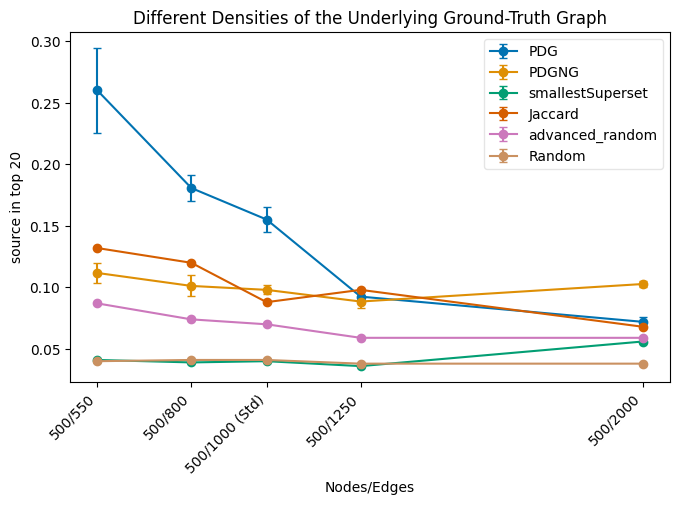

Displayed line-per-model plot for exp3: metric='source in top 20' (normalize=False)
pdgrapher ys: [0.022799999999999997, 0.0158, 0.016, 0.009999999999999998, 0.00425]
pdgraphernognn ys: [0.00675, 0.0072, 0.005600000000000001, 0.006500000000000001, 0.00525]
smallestSuperset ys: [0.003, 0.004, 0.004, 0.003, 0.005]
overlap ys: [0.011, 0.011, 0.007, 0.011, 0.005]
advanced_random ys: [0.003, 0.004, 0.002, 0.003, 0.002]
random ys: [0.002, 0.002, 0.001, 0.001, 0.001]


/tmp/ipykernel_3924784/1132287219.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


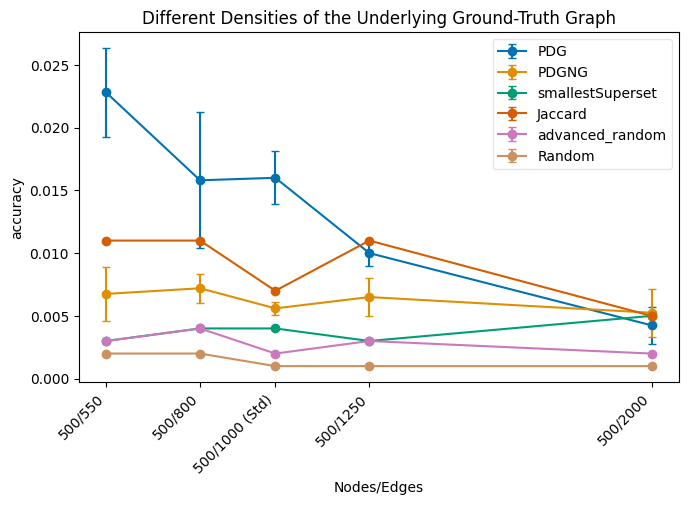

Displayed line-per-model plot for exp3: metric='accuracy' (normalize=False)
pdgrapher ys: [0.16717600000000002, 0.23028679999999996, 0.2380856, 0.288593, 0.27049900000000004]
pdgraphernognn ys: [0.22987749999999998, 0.24729800000000002, 0.26604039999999995, 0.287243, 0.2587795]
smallestSuperset ys: [0.514544, 0.4984940000000001, 0.506204, 0.508216, 0.45711399999999996]
overlap ys: [0.26842200000000005, 0.26330000000000003, 0.278198, 0.294916, 0.312486]
advanced_random ys: [0.247518, 0.26364, 0.270794, 0.30353600000000003, 0.32340800000000003]
random ys: [0.50387, 0.5025620000000001, 0.48638600000000004, 0.5102679999999999, 0.502692]


/tmp/ipykernel_3924784/1132287219.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


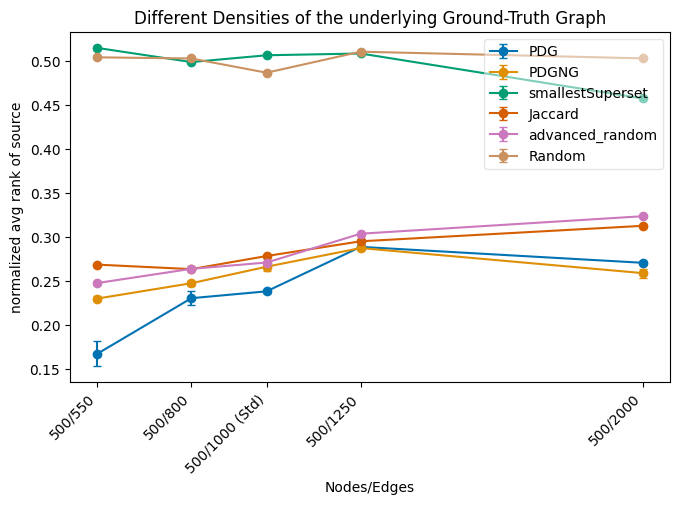

Displayed line-per-model plot for exp3: metric='avg rank of source' (normalize=True)


In [6]:
def line_plot_metric(exp: str, metric: str, title: str = None, normalize: bool = False, preferred_model_types=None, strict: bool = True):
    """Plot a line chart with one line per model type for a given experiment.

    - x-axis: numeric value extracted from variant folder names (chooses the numeric token
      position that varies across the variants).
    - one line per model type showing the metric value across variants
    - shows errorbars using per-variant std where available

    Extraction strategy:
    - For each variant name (e.g. 'exp3_500_550' or 'exp4_100_200'), extract all integers from
      the suffix (part after 'expN_'). Choose the integer position (index) which varies the
      most across variants and use that as the x-value.

    Parameters:
    - exp: experiment key (group name)
    - metric: metric path (passed to extract_metric)
    - title: optional plot title
    - normalize: if True, normalize values by num_nodes when available
    - preferred_model_types: optional ordering/filtering of model types
    - strict: if True, raise on missing data; otherwise skip missing points/lines
    """
    dfs_info = load_variant_dfs(exp, strict=strict)
    if not dfs_info:
        raise ValueError(f"No variants found for experiment '{exp}'")

    # compute per-variant statistics
    available_variants, means_list, stds_list, model_types_set = compute_stats_per_variant(dfs_info, metric, normalize=normalize)
    if not available_variants:
        raise ValueError(f"No data found for metric '{metric}' in experiment '{exp}'")

    # extract numeric tokens from variant suffixes
    num_pattern = re.compile(r"\d+")
    suffix_nums = []
    max_len = 0
    for v in available_variants:
        if v.startswith(exp + '_'):
            suffix = v[len(exp) + 1:]
        else:
            suffix = v
        nums = [int(x) for x in num_pattern.findall(suffix)]
        suffix_nums.append(nums)
        max_len = max(max_len, len(nums))

    # choose the numeric position (index) that varies the most across variants
    best_idx = None
    best_unique = -1
    for idx in range(max_len):
        vals = [nums[idx] if idx < len(nums) else None for nums in suffix_nums]
        unique_vals = len(set([v for v in vals if v is not None]))
        if unique_vals > best_unique:
            best_unique = unique_vals
            best_idx = idx

    if best_idx is None or best_unique <= 1:
        raise ValueError(f"Cannot determine a varying numeric component in variant names for experiment '{exp}'. Found tokens: {suffix_nums}")

    # build x-values aligned to available_variants (use NaN where missing)
    x_vals = [nums[best_idx] if best_idx < len(nums) else float('nan') for nums in suffix_nums]

    model_types = select_model_types(model_types_set, preferred=preferred_model_types)
    model_names = {"overlap": "Jaccard",
                   "random": "Random",
                   "pdgrapher": "PDG",
                   "pdgraphernognn": "PDGNG"}
    model_display = [model_names.get(mt, mt) for mt in model_types]

    fig, ax = create_fixed_axes()
    palette = sns.color_palette('colorblind')

    any_plotted = False
    for j, mt in enumerate(model_types):
        pts = []  # (x, y, yerr)
        for i, v in enumerate(available_variants):
            x = x_vals[i]
            y = means_list[i].get(mt, float('nan'))
            yerr = stds_list[i].get(mt, float('nan')) if (stds_list[i] is not None) else float('nan')
            if pd.isna(x) or pd.isna(y):
                continue
            pts.append((float(x), float(y), float(yerr) if not pd.isna(yerr) else float('nan')))

        if not pts:
            msg = f"No data for model_type '{mt}' in experiment '{exp}'."
            if strict:
                raise ValueError(msg)
            else:
                print('Warning:', msg, 'Skipping this model_type.')
                continue

        # sort points by x so lines plot correctly
        pts.sort(key=lambda t: t[0])
        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]
        print(f"{mt} ys: {ys}")
        errs = [p[2] for p in pts]

        ax.errorbar(xs, ys, yerr=errs, marker='o', label=model_names.get(mt, mt), color=palette[j % len(palette)], capsize=3)
        any_plotted = True

    if not any_plotted:
        raise ValueError(f"No plotted data for experiment '{exp}' and metric '{metric}'.")

    # set sensible x ticks (unique sorted x-values)
    uniq_xs = sorted(set([x for x in x_vals if not pd.isna(x)]))
    if uniq_xs:
        ax.set_xticks(uniq_xs)
        ax.set_xticklabels([str(int(x)) for x in uniq_xs], rotation=45, ha='right')
        #ax.set_xticklabels(["100/200", "250/500", "500/1000 (Std)", "600/1200"], rotation=45, ha='right')
        ax.set_xticklabels(["500/550", "500/800", "500/1000 (Std)", "500/1250", "500/2000"], rotation=45, ha='right')

    ax.set_xlabel('Nodes/Edges')
    ax.set_ylabel(("normalized " if normalize else "") + metric)
    ax.set_title(title if title is not None else f"{exp}: {metric}")
    ax.legend(loc='best', framealpha=0.5)
    fig.tight_layout()
    plt.show()
    print(f"Displayed line-per-model plot for {exp}: metric='{metric}' (normalize={normalize})")

# # Example (uncomment to run):
line_plot_metric('exp3', 'source in top 20', title='Different Densities of the Underlying Ground-Truth Graph')
line_plot_metric('exp3', 'accuracy', title='Different Densities of the Underlying Ground-Truth Graph')
line_plot_metric('exp3', 'avg rank of source', normalize=True, title='Different Densities of the underlying Ground-Truth Graph')
# line_plot_metric('exp4', 'source in top 20', title='Different Sizes of the underlying Ground-Truth Graph')
# line_plot_metric('exp4', 'accuracy', title='Different Sizes of the underlying Ground-Truth Graph')
# line_plot_metric('exp4', 'avg rank of source', normalize=True)


0.166
0.34933333333333333
0.11499999999999999
0.38079999999999997
0.205
0.486
0.396
0.484
0.074
0.071
0.036
0.037


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


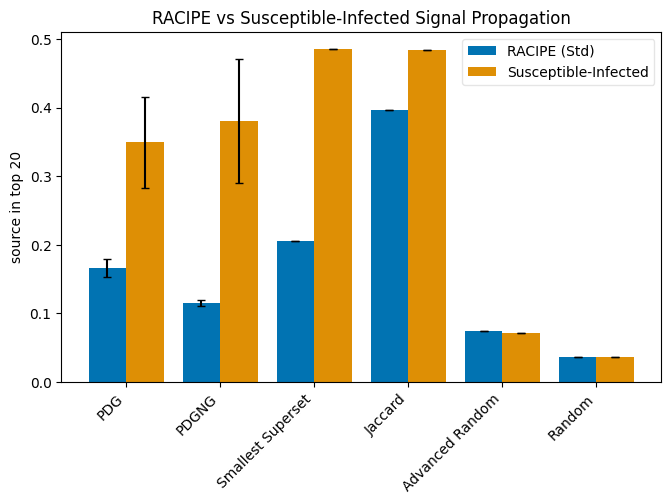

Displayed plot for expsi: metric='source in top 20' (normalize=False)
0.2380392
0.14101533333333335
0.262309
0.1212304
0.29378
0.075972
0.12978399999999998
0.07563800000000001
0.28075599999999995
0.27788
0.504074
0.498782


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


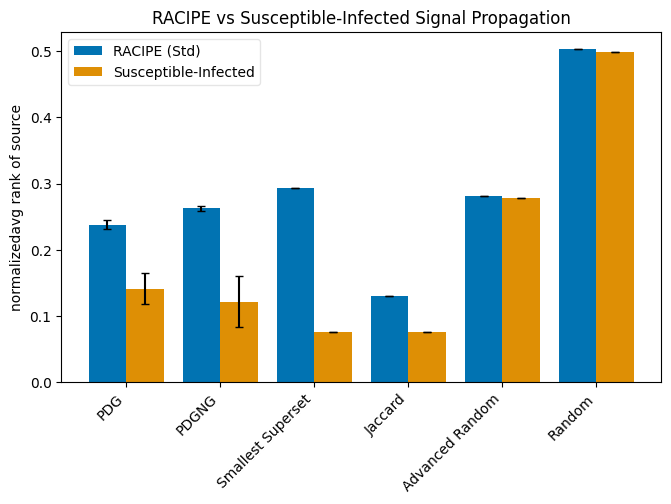

Displayed plot for expsi: metric='avg rank of source' (normalize=True)
0.3041545643153527
0.2909903181189488
0.3791244813278008
0.510844398340249
0.48026763485477175
0.49652904564315353


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


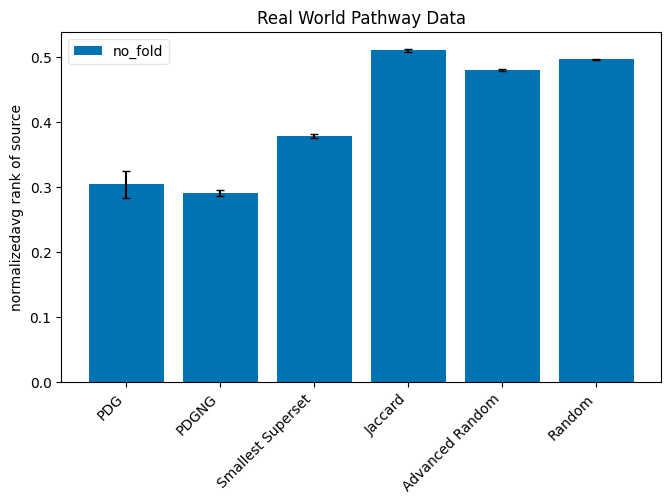

Displayed plot for pathway: metric='avg rank of source' (normalize=True)


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


0.31625000000000003
0.314
0.138
0.0745
0.087
0.08349999999999999


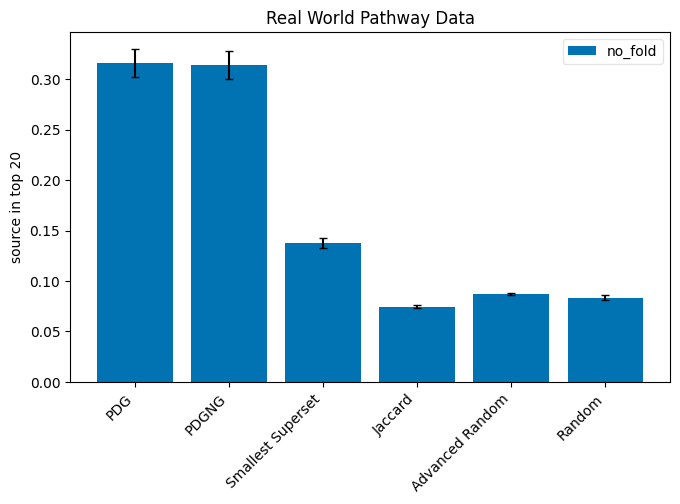

Displayed plot for pathway: metric='source in top 20' (normalize=False)
0.06125
0.078
0.020999999999999998
0.0035
0.004
0.0045000000000000005


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


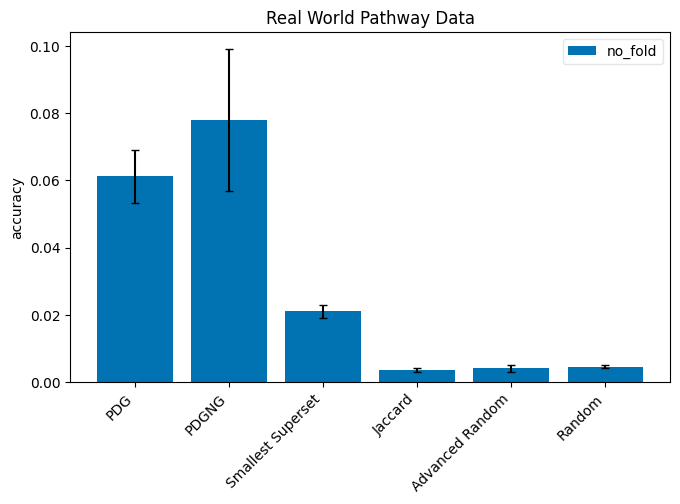

Displayed plot for pathway: metric='accuracy' (normalize=False)


In [7]:
plot_metric("expsi", "source in top 20", strict=False, title="RACIPE vs Susceptible-Infected Signal Propagation", collapse_pdgraphernognn=False)
plot_metric("expsi", "avg rank of source", normalize=True, strict=False, title="RACIPE vs Susceptible-Infected Signal Propagation", collapse_pdgraphernognn=False)
plot_metric("pathway", "avg rank of source", normalize=True, strict=False, title="Real World Pathway Data", collapse_pdgraphernognn=False)
plot_metric("pathway", "source in top 20", normalize=False, strict=False, title="Real World Pathway Data", collapse_pdgraphernognn=False)
plot_metric("pathway", "accuracy", normalize=False, strict=False, title="Real World Pathway Data", collapse_pdgraphernognn=False)

2     0.068571
8     0.070000
14    0.077143
20    0.080000
26    0.078800
32    0.113500
38    0.155200
44    0.167500
Name: mean, dtype: float64
3     0.070500
9     0.064000
15    0.073667
21    0.074500
27    0.080400
33    0.087000
39    0.098000
45    0.092667
Name: mean, dtype: float64


/tmp/ipykernel_3924784/606565160.py:555: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


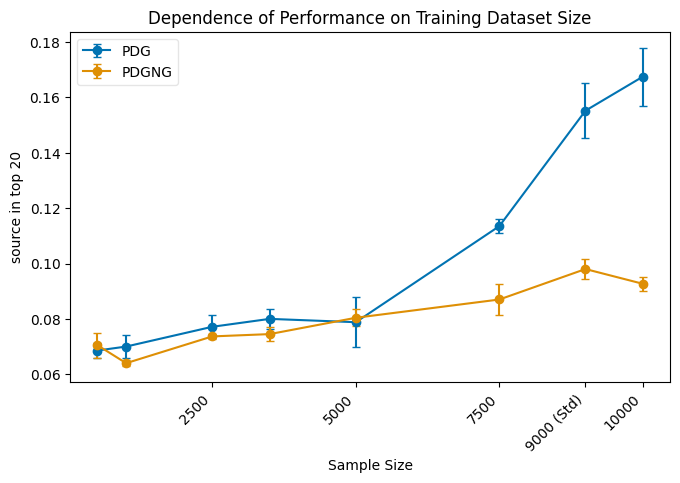

Displayed sample size plot for metric='source in top 20' (normalize=False)
baseline avg: 0.09632708333333333
[np.float64(0.1552), np.float64(0.11339999999999999), np.float64(0.10700000000000001), np.float64(0.097), np.float64(0.10259999999999998), np.float64(0.0986), np.float64(0.096), np.float64(0.086)]


/tmp/ipykernel_3924784/606565160.py:418: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


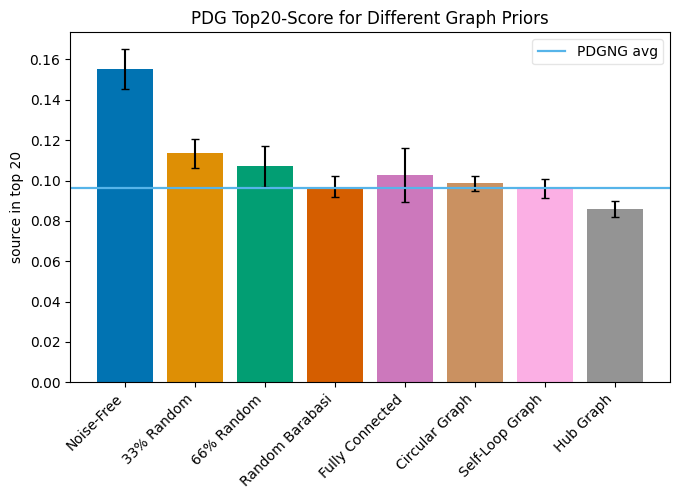

Displayed pdgrapher - pdgraphernognn difference plot for exp2: metric='source in top 20' (normalize=False)
baseline avg: 0.005864583333333334
[np.float64(0.016), np.float64(0.0116), np.float64(0.0078), np.float64(0.0064), np.float64(0.005600000000000001), np.float64(0.0062), np.float64(0.0068000000000000005), np.float64(0.0058000000000000005)]


/tmp/ipykernel_3924784/606565160.py:418: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


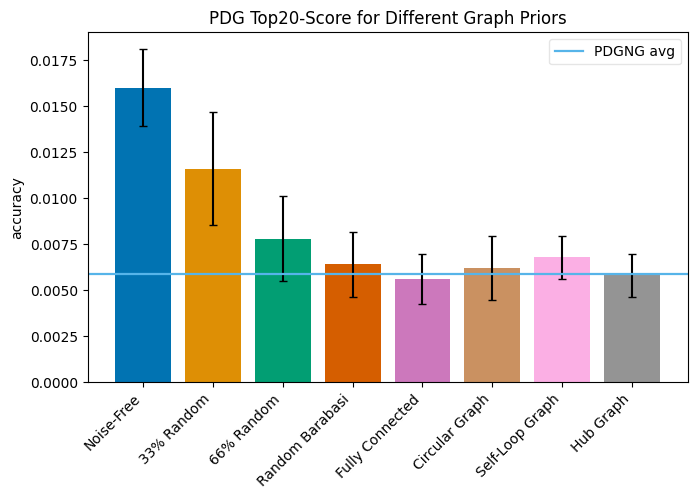

Displayed pdgrapher - pdgraphernognn difference plot for exp2: metric='accuracy' (normalize=False)
baseline avg: 0.2652313708333333
[np.float64(0.2380856), np.float64(0.24996959999999996), np.float64(0.257316), np.float64(0.26461959999999995), np.float64(0.24876319999999996), np.float64(0.2634964), np.float64(0.2648136), np.float64(0.27217240000000004)]


/tmp/ipykernel_3924784/606565160.py:418: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


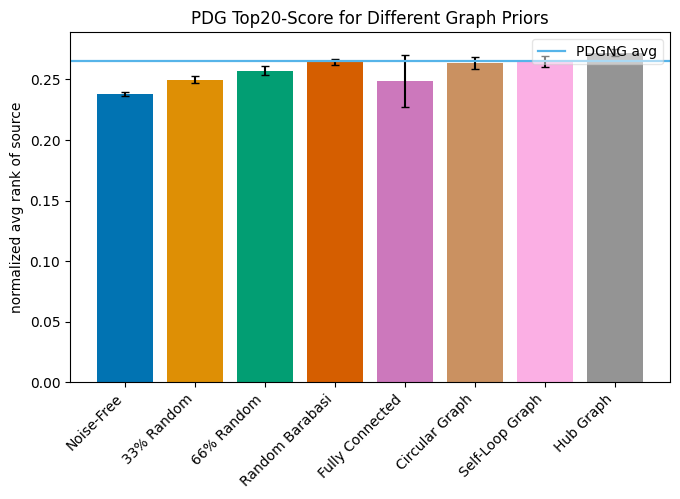

Displayed pdgrapher - pdgraphernognn difference plot for exp2: metric='avg rank of source' (normalize=True)


In [8]:
sample_size_bars('source in top 20', normalize=False)
# sample_size_bars('accuracy', normalize=False)
# sample_size_bars('avg rank of source', normalize=True)
plot_pdgrapher_with_nognn_hline('exp2', 'source in top 20', normalize=False, strict=False, title="PDG Top20-Score for Different Graph Priors")
plot_pdgrapher_with_nognn_hline('exp2', 'accuracy', normalize=False, strict=False, title="PDG Top20-Score for Different Graph Priors")
plot_pdgrapher_with_nognn_hline('exp2', 'avg rank of source', normalize=True, strict=False, title="PDG Top20-Score for Different Graph Priors")

In [9]:
exp = "exp1"
metric = "source in top 20"
normalize = False


dfs_info = load_variant_dfs(exp)
available_variants, means_list, stds_list, model_types_set = compute_stats_per_variant(dfs_info, metric, normalize=normalize)
means_list

[advanced_random     0.070000
 overlap             0.088000
 pdgrapher           0.148167
 pdgraphernognn      0.098000
 random              0.041000
 smallestSuperset    0.040000
 dtype: float64,
 advanced_random     0.0700
 overlap             0.0950
 pdgrapher           0.1134
 pdgraphernognn      0.0926
 random              0.0410
 smallestSuperset    0.0400
 dtype: float64,
 advanced_random     0.0720
 overlap             0.0870
 pdgrapher           0.1070
 pdgraphernognn      0.0968
 random              0.0410
 smallestSuperset    0.0400
 dtype: float64,
 advanced_random     0.04100
 overlap             0.04000
 pdgrapher           0.09700
 pdgraphernognn      0.09275
 random              0.04100
 smallestSuperset    0.04000
 dtype: float64]

0.24168033333333336
0.24996959999999996
0.257316
0.26461959999999995
0.265520475
0.506204
0.506204
0.506204
0.506204
0.278198
0.302346
0.29952
0.506204
0.270794
0.289156
0.291854
0.4863860000000001
0.4863860000000001


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


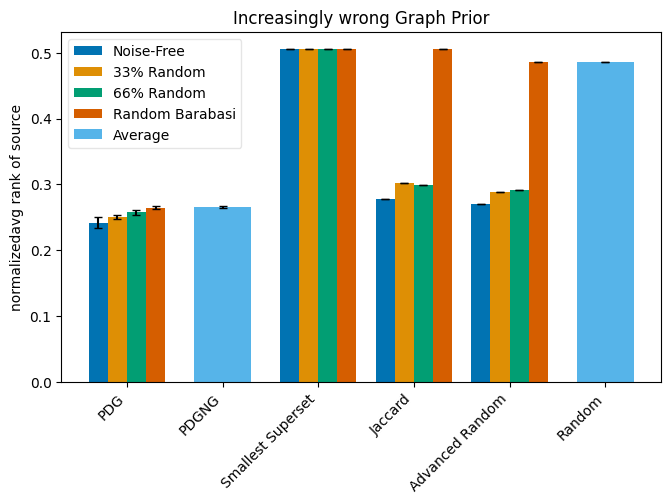

Displayed plot for exp1: metric='avg rank of source' (normalize=True)
0.014166666666666668
0.0116
0.0078
0.0064
0.0057375
0.004
0.004
0.004
0.004
0.007
0.005
0.008
0.004
0.002
0.002
0.002
0.001
0.001


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


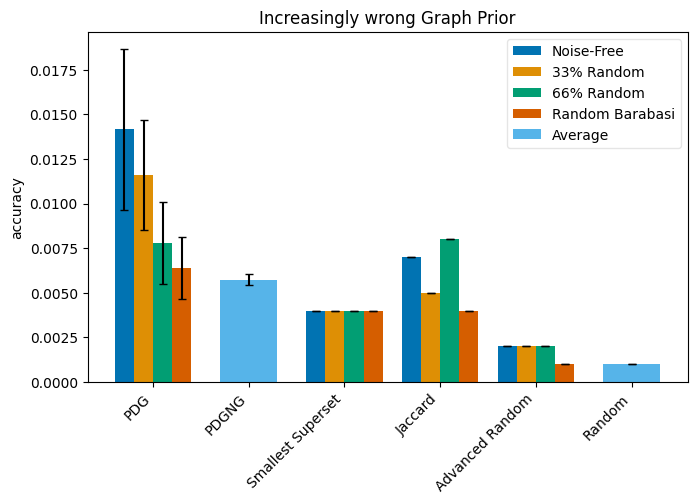

Displayed plot for exp1: metric='accuracy' (normalize=False)
0.2380856
0.24996959999999996
0.257316
0.26461959999999995
0.24876319999999996
0.2634964
0.2648136
0.27217240000000004
0.2652313708333333
0.506204
0.506204
0.506204
0.506204
0.506204
0.506204
0.506204
0.506702
0.278198
0.302346
0.29952
0.506204
0.506204
0.506204
0.501088
0.50552
0.270794
0.289156
0.291854
0.4863860000000001
0.48638600000000004
0.4863860000000001
0.4863860000000001
0.506702
0.4863860000000001


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


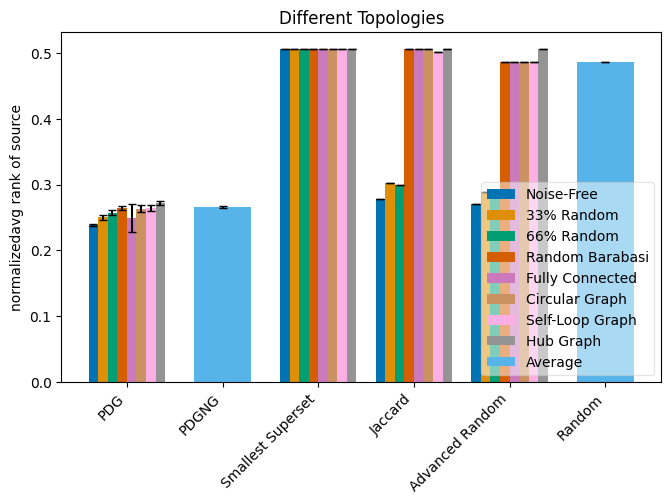

Displayed plot for exp2: metric='avg rank of source' (normalize=True)
0.32850999999999997
0.332044
0.2380856
0.20146333333333333
0.3445325
0.349056
0.26604039999999995
0.20522916666666666
0.49364
0.5180800000000001
0.506204
0.5023816666666666
0.33744
0.36380399999999996
0.278198
0.23493333333333336
0.34244
0.384464
0.270794
0.22493333333333335
0.48582
0.49445999999999996
0.48638600000000004
0.499195


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


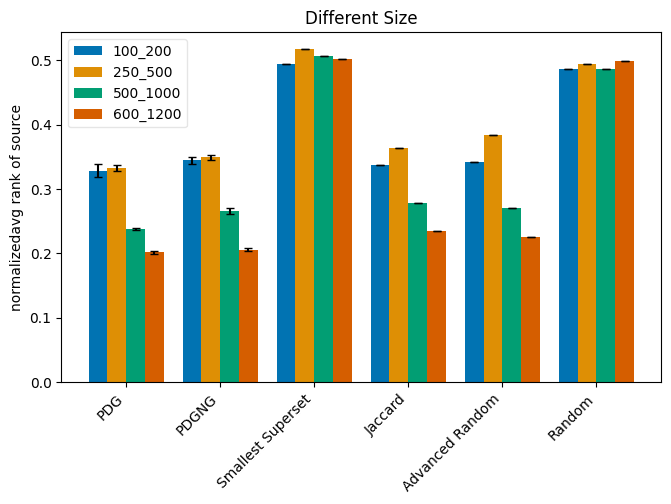

Displayed plot for exp4: metric='avg rank of source' (normalize=True)
0.3897474285714286
0.36576257142857144
0.2859317142857143
0.2819205
0.27692440000000007
0.2626825
0.2380856
0.2391215
0.40072399999999997
0.366953
0.2876493333333333
0.28009399999999995
0.28186920000000004
0.269046
0.26604039999999995
0.26569333333333334
0.517212
0.515222
0.512824
0.5129640000000001
0.514396
0.514476
0.506204
0.514974
0.276362
0.28001
0.282986
0.28282799999999997
0.280964
0.28043599999999996
0.278198
0.27941000000000005
0.27932
0.278514
0.28082999999999997
0.28033800000000003
0.276734
0.277304
0.270794
0.27975599999999995
0.501252
0.500062
0.5039239999999999
0.502958
0.4972200000000001
0.498114
0.48638600000000004
0.5024580000000001


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


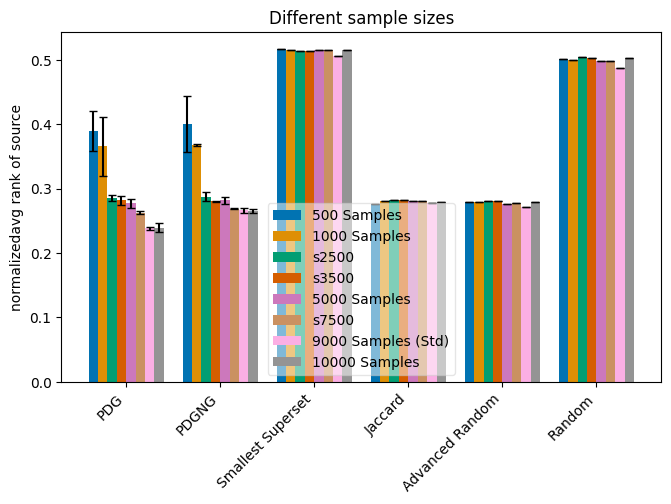

Displayed plot for exp5: metric='avg rank of source' (normalize=True)


In [10]:
# Example usages:
plot_metric("exp1", "avg rank of source", normalize=True, strict=False, title="Increasingly wrong Graph Prior")
plot_metric("exp1", "accuracy", normalize=False, strict=False, title="Increasingly wrong Graph Prior")
plot_metric("exp2", "avg rank of source", normalize=True, strict=False, title="Different Topologies")
# plot_metric("exp3", "avg rank of source", normalize=True, strict=False, title="Different Connectivities")
plot_metric("exp4", "avg rank of source", normalize=True, strict=False, title="Different Size",collapse_pdgraphernognn=False)
plot_metric("exp5", "avg rank of source", normalize=True, strict=False, title="Different sample sizes", collapse_pdgraphernognn=False)

0.166
0.34933333333333333
0.11499999999999999
0.38079999999999997
0.205
0.486
0.396
0.484
0.074
0.071
0.036
0.037


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


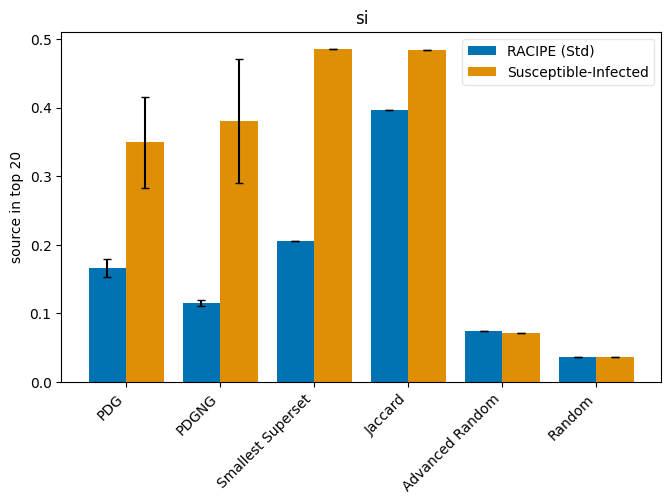

Displayed plot for expsi: metric='source in top 20' (normalize=False)
0.166
0.1552
0.11499999999999999
0.098
0.205
0.04
0.396
0.08799999999999998
0.074
0.07
0.036
0.041


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


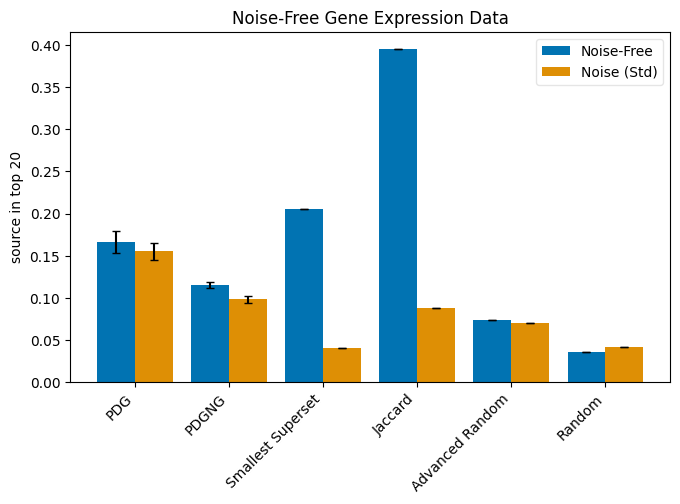

Displayed plot for exp0: metric='source in top 20' (normalize=False)
0.020999999999999998
0.016
0.006999999999999999
0.005600000000000001
0.129
0.004
0.10900000000000001
0.007
0.004
0.002
0.001
0.001


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


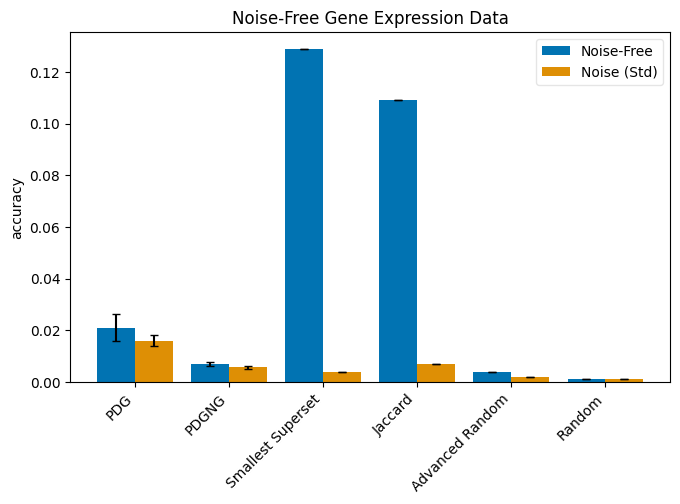

Displayed plot for exp0: metric='accuracy' (normalize=False)
0.2380392
0.2380856
0.262309
0.26604039999999995
0.29378
0.506204
0.12978399999999998
0.278198
0.28075599999999995
0.270794
0.504074
0.48638600000000004


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


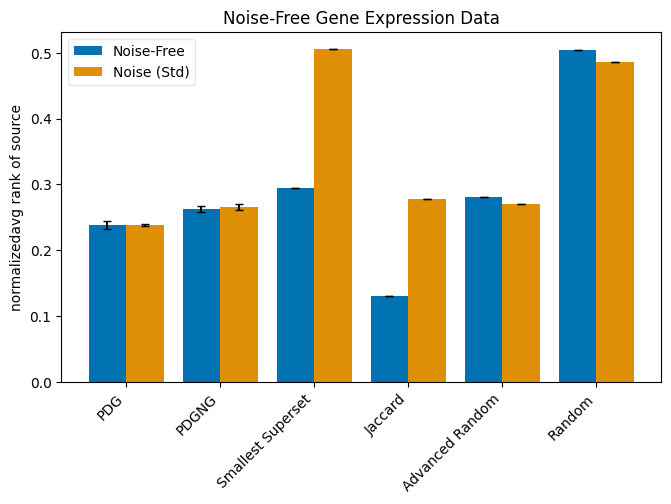

Displayed plot for exp0: metric='avg rank of source' (normalize=True)
0.14816666666666667
0.11339999999999999
0.10700000000000001
0.097
0.0950375
0.04
0.04
0.04
0.04
0.088
0.095
0.087
0.04
0.07
0.07
0.072
0.041
0.041


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


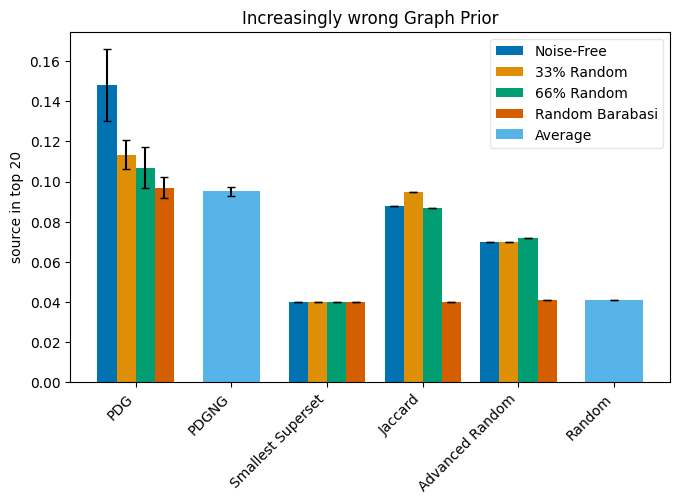

Displayed plot for exp1: metric='source in top 20' (normalize=False)
0.1552
0.11339999999999999
0.10700000000000001
0.097
0.10259999999999998
0.0986
0.096
0.086
0.09632708333333333
0.04
0.04
0.04
0.04
0.04
0.04
0.04
0.036
0.08799999999999998
0.095
0.087
0.04
0.04
0.04
0.028000000000000004
0.026000000000000002
0.07
0.07
0.072
0.041
0.041
0.041
0.041
0.036
0.041


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


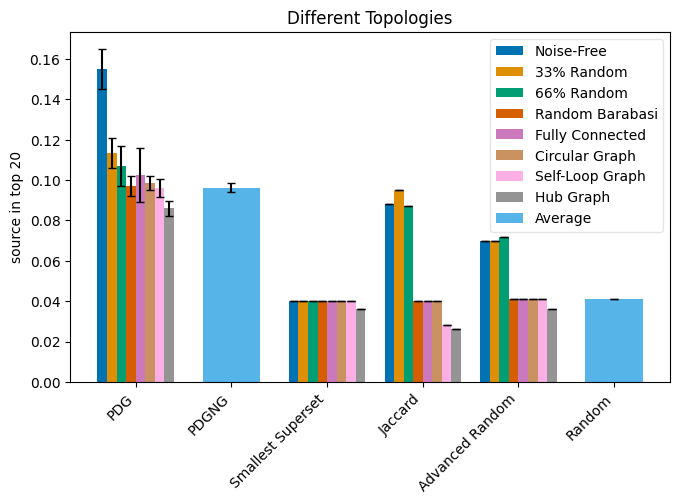

Displayed plot for exp2: metric='source in top 20' (normalize=False)
0.26020000000000004
0.1808
0.1552
0.0925
0.07200000000000001
0.11175
0.1012
0.098
0.0885
0.10275
0.041
0.039
0.04
0.036
0.056
0.132
0.12
0.08799999999999998
0.098
0.068
0.087
0.074
0.07
0.059
0.059
0.04
0.041
0.041
0.038
0.038


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


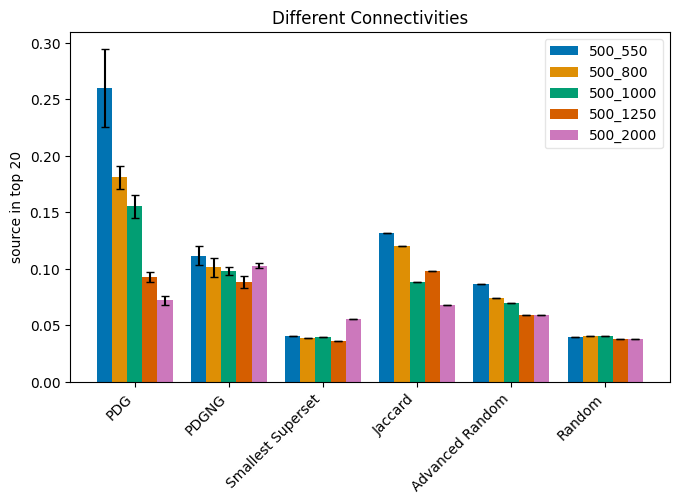

Displayed plot for exp3: metric='source in top 20' (normalize=False)
0.3328
0.2095
0.1552
0.1315
0.30175
0.15633333333333332
0.098
0.11149999999999999
0.212
0.073
0.04
0.023
0.286
0.141
0.08799999999999998
0.098
0.307
0.116
0.07
0.075
0.215
0.09000000000000001
0.041
0.032


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


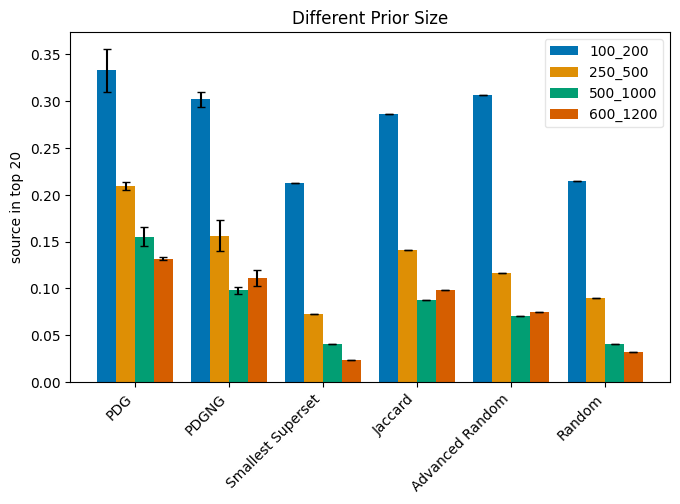

Displayed plot for exp4: metric='source in top 20' (normalize=False)
0.06857142857142857
0.07
0.07714285714285715
0.08
0.07880000000000001
0.1135
0.1552
0.16749999999999998
0.07050000000000001
0.064
0.07366666666666666
0.0745
0.0804
0.087
0.098
0.09266666666666667
0.042
0.043
0.041
0.04
0.041
0.04
0.04
0.044000000000000004
0.096
0.091
0.09100000000000001
0.088
0.09
0.089
0.08799999999999998
0.09300000000000001
0.066
0.074
0.074
0.066
0.073
0.07
0.07
0.072
0.036
0.044
0.038
0.037
0.04
0.039
0.041
0.042


/tmp/ipykernel_3924784/606565160.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


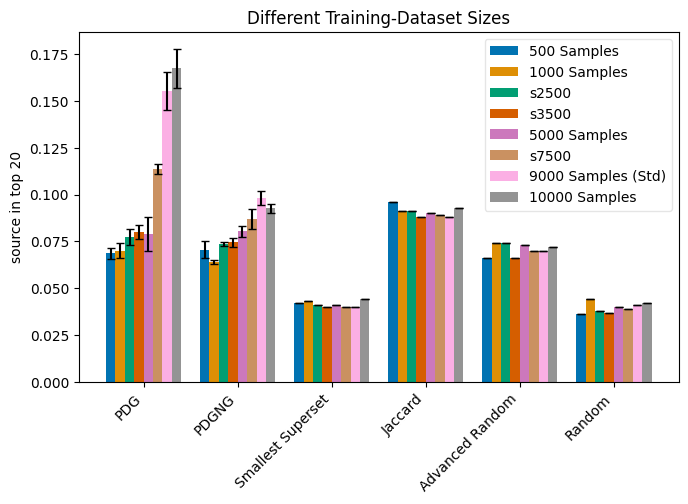

Displayed plot for exp5: metric='source in top 20' (normalize=False)


In [11]:
# Example usages:
plot_metric("expsi", "source in top 20", strict=False, title="si", collapse_pdgraphernognn=False)
plot_metric("exp0", "source in top 20", strict=False, title="Noise-Free Gene Expression Data", collapse_pdgraphernognn=False)
plot_metric("exp0", "accuracy", strict=False, title="Noise-Free Gene Expression Data", collapse_pdgraphernognn=False)
plot_metric("exp0", "avg rank of source", normalize=True, strict=False, title="Noise-Free Gene Expression Data", collapse_pdgraphernognn=False)
plot_metric("exp1", "source in top 20", strict=False, title="Increasingly wrong Graph Prior")
plot_metric("exp2", "source in top 20", strict=False, title="Different Topologies")
plot_metric("exp3", "source in top 20", strict=False, title="Different Connectivities", collapse_pdgraphernognn=False)
plot_metric("exp4", "source in top 20", strict=False, title="Different Prior Size", collapse_pdgraphernognn=False)
plot_metric("exp5", "source in top 20", strict=False, title="Different Training-Dataset Sizes", collapse_pdgraphernognn=False)

# plot_metric("exp4", "source in top 20", strict=False, title="Different Size")
# plot_metric("exp5", "source in top 20", strict=False, title="Different sample sizes")

In [12]:
# plot_model_variants_against_baseline("exp2", "avg rank of source", model_type="pdgrapher", baseline="pdgraphernognn", normalize=True, title="Effect of different topologies on PDGrapher")
# plot_model_variants_against_baseline("exp2", "source in top 20", model_type="pdgrapher", baseline="pdgraphernognn", normalize=True, title="Effect of different topologies on PDGrapher")
# plot_model_variants_against_baseline("exp3", "source in top 20", model_type="pdgrapher", baseline="pdgraphernognn", normalize=True, title="Effect of different topologies on PDGrapher")

[np.float64(0.05100000000000002), np.float64(0.0572)]


/tmp/ipykernel_3924784/606565160.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


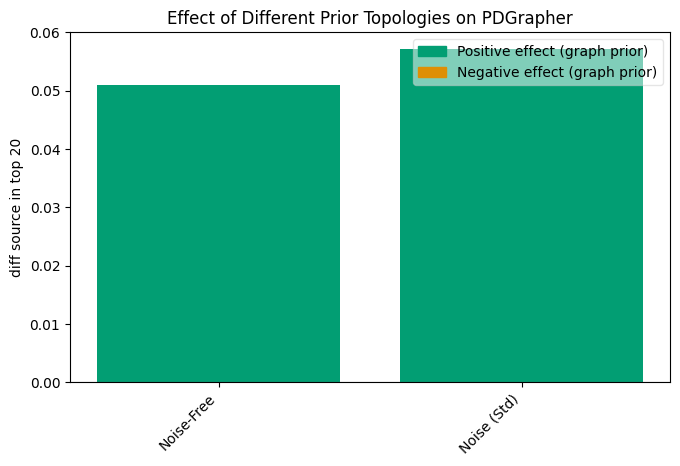

Displayed difference plot for exp0: pdgrapher - pdgraphernognn on metric='source in top 20' (normalize=False)
[np.float64(0.05887291666666668), np.float64(0.01707291666666666), np.float64(0.010672916666666685), np.float64(0.0006729166666666758), np.float64(0.006272916666666656), np.float64(0.002272916666666666), np.float64(-0.00032708333333332507), np.float64(-0.010327083333333334)]


/tmp/ipykernel_3924784/606565160.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


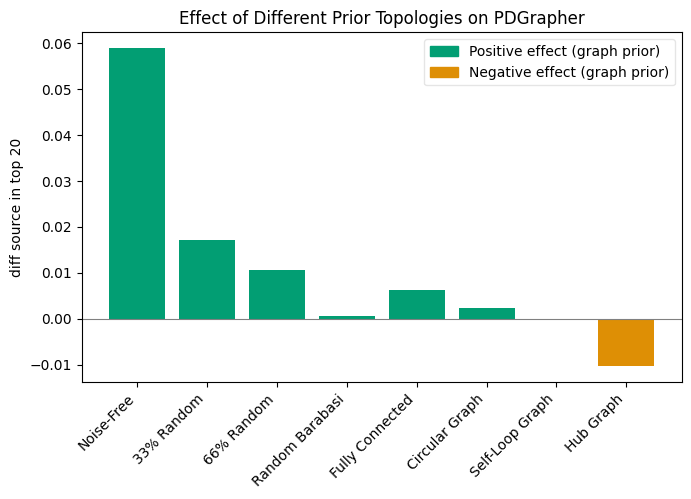

Displayed difference plot for exp2: pdgrapher - pdgraphernognn on metric='source in top 20' (normalize=False)
[np.float64(-0.027145770833333305), np.float64(-0.015261770833333355), np.float64(-0.007915370833333324), np.float64(-0.0006117708333333582), np.float64(-0.01646817083333335), np.float64(-0.0017349708333332936), np.float64(-0.00041777083333333076), np.float64(0.006941029166666723)]


/tmp/ipykernel_3924784/606565160.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


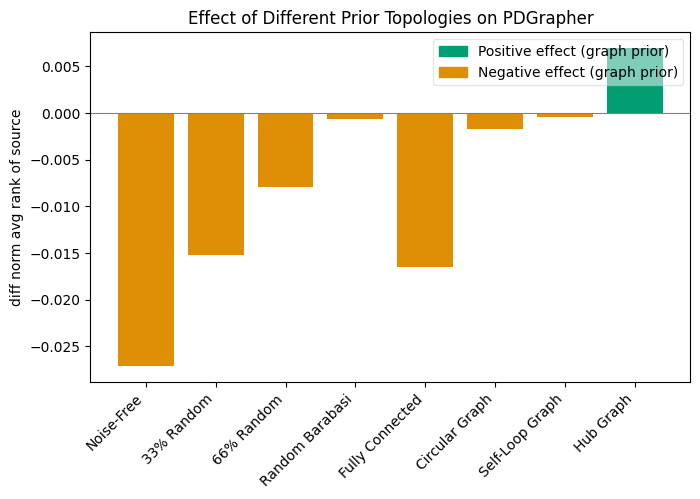

Displayed difference plot for exp2: pdgrapher - pdgraphernognn on metric='avg rank of source' (normalize=True)
[np.float64(0.14845000000000003), np.float64(0.07959999999999999), np.float64(0.0572), np.float64(0.0040000000000000036), np.float64(-0.030749999999999986)]


/tmp/ipykernel_3924784/606565160.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


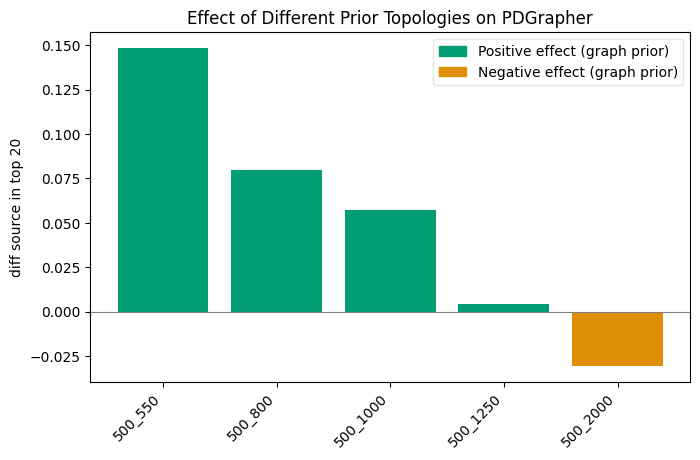

Displayed difference plot for exp3: pdgrapher - pdgraphernognn on metric='source in top 20' (normalize=False)
[np.float64(0.031049999999999967), np.float64(0.05316666666666667), np.float64(0.0572), np.float64(0.020000000000000018)]


/tmp/ipykernel_3924784/606565160.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


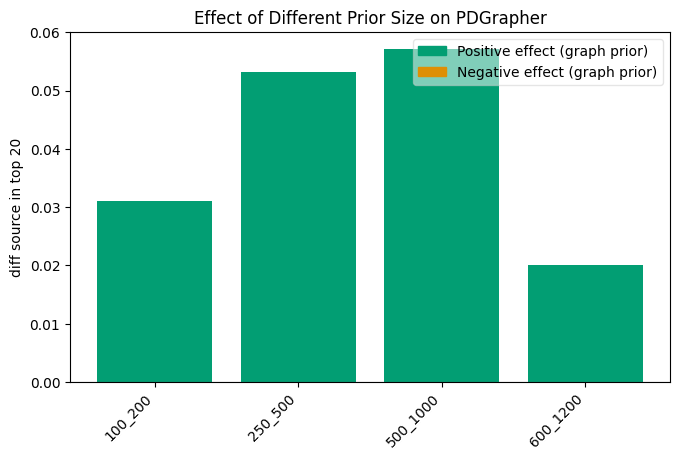

Displayed difference plot for exp4: pdgrapher - pdgraphernognn on metric='source in top 20' (normalize=False)
[np.float64(-0.0019285714285714323), np.float64(0.006000000000000005), np.float64(0.003476190476190494), np.float64(0.005500000000000005), np.float64(-0.0015999999999999903), np.float64(0.02650000000000001), np.float64(0.0572), np.float64(0.07483333333333331)]


/tmp/ipykernel_3924784/606565160.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


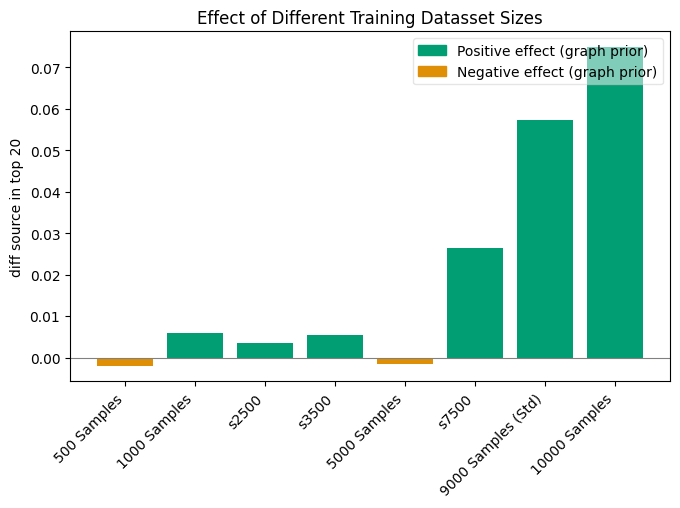

Displayed difference plot for exp5: pdgrapher - pdgraphernognn on metric='source in top 20' (normalize=False)


In [13]:

# Example of difference-plot for a single experiment (change strict to True to enforce presence)
# plot_model_difference("exp2", "avg rank of source", "pdgrapher", "pdgraphernognn", normalize=True, strict=False, title = "Effect of different topologies on PDGrapher")
plot_model_difference("exp0", "source in top 20", "pdgrapher", "pdgraphernognn", strict=False, title = "Effect of Different Prior Topologies on PDGrapher", summarize_baseline=False)
plot_model_difference("exp2", "source in top 20", "pdgrapher", "pdgraphernognn", strict=False, title = "Effect of Different Prior Topologies on PDGrapher", summarize_baseline=True)
plot_model_difference("exp2", "avg rank of source", "pdgrapher", "pdgraphernognn", normalize=True, strict=False, title = "Effect of Different Prior Topologies on PDGrapher", summarize_baseline=True)
plot_model_difference("exp3", "source in top 20", "pdgrapher", "pdgraphernognn", strict=False, title = "Effect of Different Prior Topologies on PDGrapher", summarize_baseline=False)
plot_model_difference("exp4", "source in top 20", "pdgrapher", "pdgraphernognn", strict=False, title = "Effect of Different Prior Size on PDGrapher", summarize_baseline=False)
plot_model_difference("exp5", "source in top 20", "pdgrapher", "pdgraphernognn", strict=False, title = "Effect of Different Training Datasset Sizes", summarize_baseline=False)

[np.float64(-0.06270149999999997), np.float64(-0.01701120000000006), np.float64(-0.027954799999999946), np.float64(0.0013499999999999623), np.float64(0.01171950000000005)]


/tmp/ipykernel_3924784/606565160.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


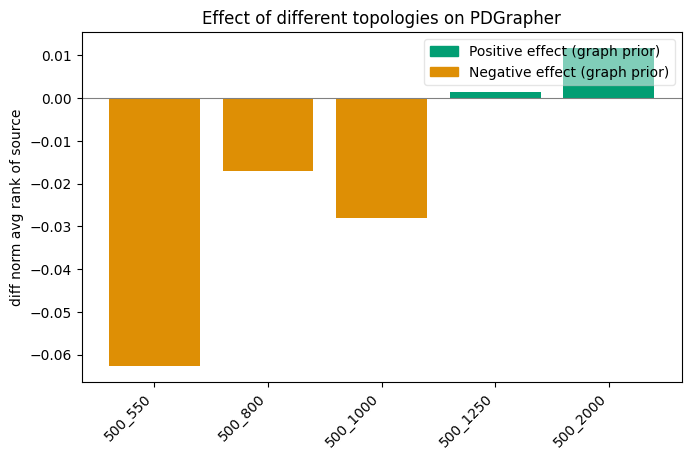

Displayed difference plot for exp3: pdgrapher - pdgraphernognn on metric='avg rank of source' (normalize=True)
[np.float64(0.14845000000000003), np.float64(0.07959999999999999), np.float64(0.0572), np.float64(0.0040000000000000036), np.float64(-0.030749999999999986)]


/tmp/ipykernel_3924784/606565160.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


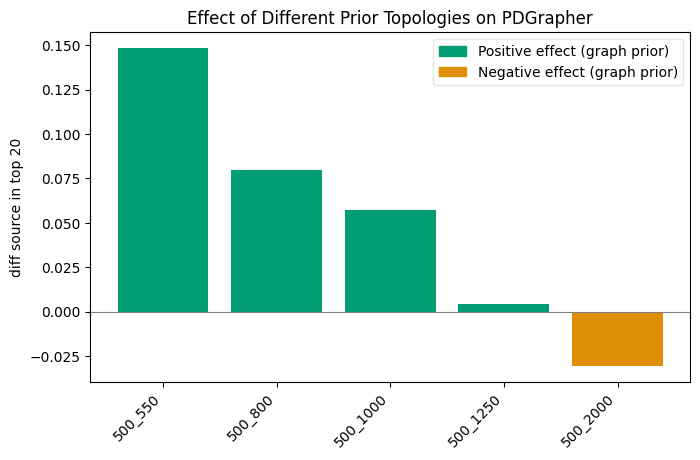

Displayed difference plot for exp3: pdgrapher - pdgraphernognn on metric='source in top 20' (normalize=False)


In [14]:
plot_model_difference("exp3", "avg rank of source", "pdgrapher", "pdgraphernognn", normalize=True, strict=False, title = "Effect of different topologies on PDGrapher")
plot_model_difference("exp3", "source in top 20", "pdgrapher", "pdgraphernognn", strict=False, title = "Effect of Different Prior Topologies on PDGrapher")

[np.float64(0.16717600000000002), np.float64(0.23028679999999996), np.float64(0.2380856), np.float64(0.288593), np.float64(0.27049900000000004)]
[np.float64(0.22987749999999998), np.float64(0.24729800000000002), np.float64(0.26604039999999995), np.float64(0.287243), np.float64(0.2587795)]


/tmp/ipykernel_3924784/606565160.py:365: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


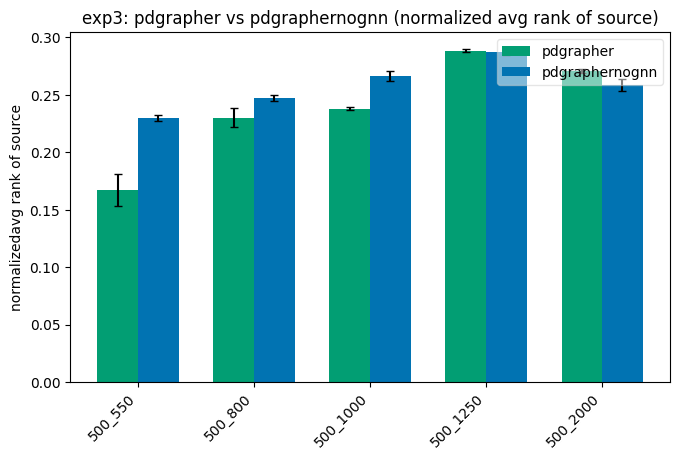

Displayed pdgrapher vs pdgraphernognn grouped plot for exp3: metric='avg rank of source' (normalize=True)


/tmp/ipykernel_3924784/606565160.py:484: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


[np.float64(-0.06270149999999997), np.float64(-0.01701120000000006), np.float64(-0.027954799999999946), np.float64(0.0013499999999999623), np.float64(0.01171950000000005)]


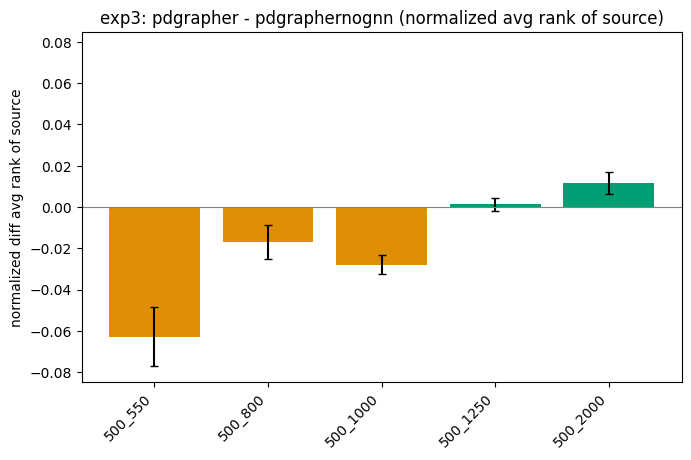

Displayed pdgrapher - pdgraphernognn difference plot for exp3: metric='avg rank of source' (normalize=True)
[np.float64(0.32850999999999997), np.float64(0.332044), np.float64(0.2380856), np.float64(0.20146333333333333)]
[np.float64(0.3445325), np.float64(0.349056), np.float64(0.26604039999999995), np.float64(0.20522916666666666)]


/tmp/ipykernel_3924784/606565160.py:365: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


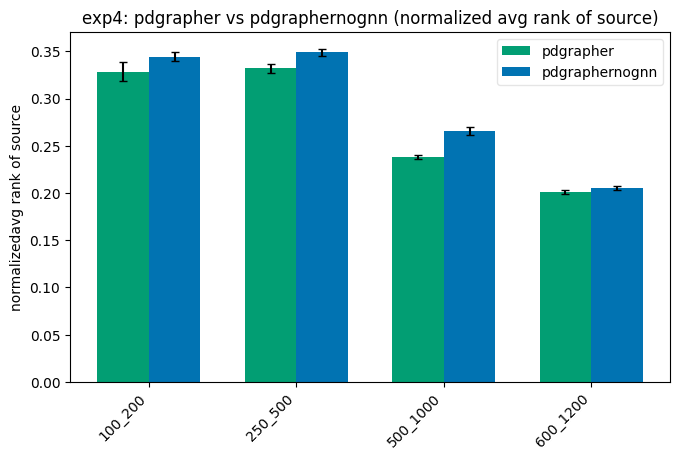

/tmp/ipykernel_3924784/606565160.py:484: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Displayed pdgrapher vs pdgraphernognn grouped plot for exp4: metric='avg rank of source' (normalize=True)
[np.float64(-0.01602250000000005), np.float64(-0.01701199999999997), np.float64(-0.027954799999999946), np.float64(-0.0037658333333333294)]


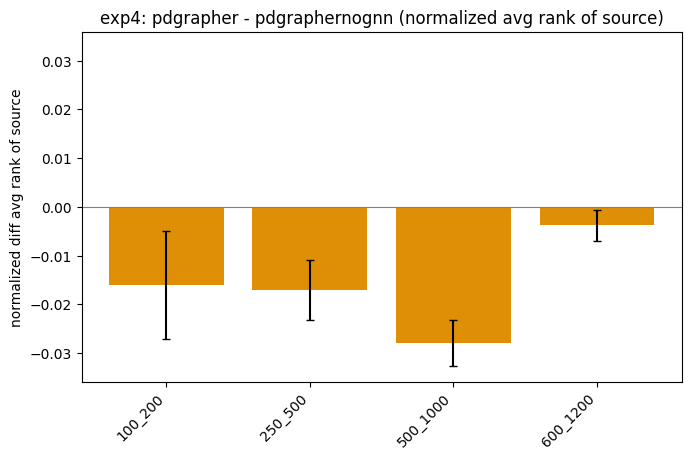

Displayed pdgrapher - pdgraphernognn difference plot for exp4: metric='avg rank of source' (normalize=True)
[np.float64(0.3897474285714286), np.float64(0.36576257142857144), np.float64(0.2859317142857143), np.float64(0.2819205), np.float64(0.27692440000000007), np.float64(0.2626825), np.float64(0.2380856), np.float64(0.2391215)]
[np.float64(0.40072399999999997), np.float64(0.366953), np.float64(0.2876493333333333), np.float64(0.28009399999999995), np.float64(0.28186920000000004), np.float64(0.269046), np.float64(0.26604039999999995), np.float64(0.26569333333333334)]


/tmp/ipykernel_3924784/606565160.py:365: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


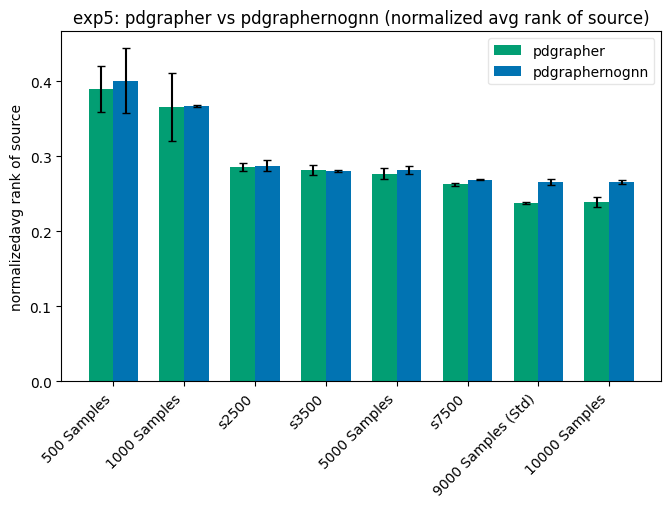

Displayed pdgrapher vs pdgraphernognn grouped plot for exp5: metric='avg rank of source' (normalize=True)
[np.float64(-0.010976571428571391), np.float64(-0.0011904285714285368), np.float64(-0.0017176190476190234), np.float64(0.0018265000000000642), np.float64(-0.0049447999999999714), np.float64(-0.006363500000000022), np.float64(-0.027954799999999946), np.float64(-0.02657183333333335)]


/tmp/ipykernel_3924784/606565160.py:484: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


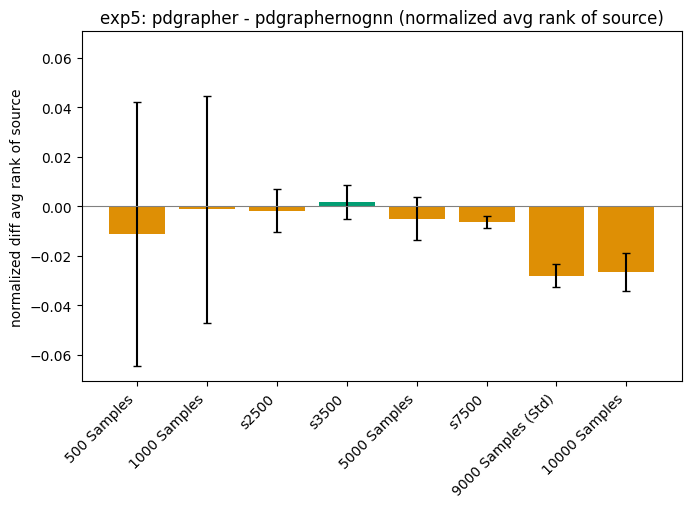

Displayed pdgrapher - pdgraphernognn difference plot for exp5: metric='avg rank of source' (normalize=True)


In [15]:
plot_pdgrapher_vs_nognn_grouped("exp3", "avg rank of source", True)
plot_pdgrapher_vs_nognn_difference("exp3", "avg rank of source", True)

plot_pdgrapher_vs_nognn_grouped("exp4", "avg rank of source", True)
plot_pdgrapher_vs_nognn_difference("exp4", "avg rank of source", True)

plot_pdgrapher_vs_nognn_grouped("exp5", "avg rank of source", True)
plot_pdgrapher_vs_nognn_difference("exp5", "avg rank of source", True)

In [16]:
def og_pdgrapher_data(folder_prefix, metric, normalize=False, title=None, pdg_metric: bool = False):
    """Plot results of experiments on og pdgrapher datasets, sorted by mean (desc)."""
    variant_folders = [f for f in os.listdir() if f.startswith(folder_prefix) and os.path.isdir(f)]
    if not variant_folders:
        raise ValueError(f"No folders found with prefix '{folder_prefix}'")
    ideal_order = ['pdgrapher_grn', 'pdgrapher_nognn', 'pdgrapher_dense', 'pdgrapher_hub']
    # remove whatever is not in ideal_order
    variant_folders = [f for f in variant_folders if f in ideal_order]
    variant_folders.sort(key=lambda f: ideal_order.index(f) if f in ideal_order else len(ideal_order))

    import json

    num_nodes = 10716  # og pdgrapher graph size
    rows = []
    for f in variant_folders:
        result_files = [rf for rf in os.listdir(f) if rf.endswith(".json")]
        if not result_files:
            raise FileNotFoundError(f"No .json result files found in folder '{f}'")
    

        metrics = []
        for rf in result_files:
            path = os.path.join(f, rf)
            with open(path, "r") as infile:
                data = json.load(infile)
                # metric is expected under data["metrics"][metric]
                if "metrics" not in data or not isinstance(data["metrics"], dict):
                    raise ValueError(f"File '{path}' missing 'metrics' dict")
                if pdg_metric:
                    val = data["metrics"]['pdgrapher_perturbation_discovery'].get(metric)
                else:
                    val = data["metrics"].get(metric)
                if val is None:
                    continue
                try:
                    val = float(val)
                except Exception:
                    raise ValueError(f"Non-numeric metric value for '{metric}' in file '{path}': {val}")
                if normalize:
                    val = val / float(num_nodes)
                metrics.append(val)

        if not metrics:
            raise ValueError(f"No metric '{metric}' values found in any .json within folder '{f}'")
        s = pd.Series(metrics)
        rows.append({"folder": f, "mean": float(s.mean()), "std": float(s.std(ddof=0))})

    # sort by mean descending
    #rows.sort(key=lambda r: r["mean"], reverse=True)

    bar_labels = {
        "nognn": "PDGNG",
        "grn": "PDG (PPI-Prior)",
        "dense": "PDG (Circular)",
        "hub": "PDG (Hub)",
    }

    x = list(range(len(rows)))
    fig, ax = create_fixed_axes()
    palette = sns.color_palette("colorblind")
    for i, r in enumerate(rows):
        label = bar_labels.get(r["folder"].replace(folder_prefix + "_", ""), r["folder"])
        print(f"{label}: mean={r['mean']}, std={r['std']}")
        ax.bar(x[i], r["mean"], width=0.6, yerr=r["std"], color=palette[i % len(palette)], label=label, capsize=3)

    ax.set_title(title if title is not None else folder_prefix)
    ax.set_xticks(x)
    ax.set_xticklabels([bar_labels.get(r["folder"].replace(folder_prefix + "_", ""), r["folder"]) for r in rows], rotation=45, ha="right")
    ax.set_ylabel(("normalized " if normalize else "") + metric)
    fig.tight_layout()
    plt.show()
    print(f"Displayed og pdgrapher data plot for '{folder_prefix}': metric='{metric}' (normalize={normalize})")


def sample_size_bars(metric: str, normalize: bool = False, eqd_suffix: str = '_eqd', pdg_metric: bool = False):
    # for this experiment  'exp5': ['exp5_s2500_eqd', 'exp5_s5000_eqd', 'exp5_s7500_eqd', 'exp5_s10000_eqd']
    # plot sample size (from folder name) vs performance for pdgrapher and pdgraphernognn
    # Additionally plot pdgrapher values for variants ending with `eqd_suffix` as a separate colored line.
    exp = 'exp5'
    dfs_info = load_variant_dfs(exp, strict=True)
    # use maps from sample_size -> mean to allow missing sizes across groups
    pdg = {}            # pdgrapher (non-eqd)
    pdg_eqd = {}        # pdgrapher for eqd variants (suffix)
    pdn = {}            # pdgraphernognn
    for v, df, num_nodes in dfs_info:
        m = re.search(r's(\d+)', v)
        if not m:
            print(f"Warning: cannot extract sample size from variant '{v}'. Skipping.")
            continue
        size = int(m.group(1))
        means = {}
        for mt, group in df.groupby("model_type"):
            metrics = []
            for r in group.to_dict(orient="records"):
                val = extract_metric(r, metric, pdg_metric=pdg_metric)
                if val is None:
                    continue
                if normalize:
                    if num_nodes is None:
                        raise ValueError(f"Cannot normalize variant '{v}' by num_nodes: num_nodes missing.")
                    val = float(val) / float(num_nodes)
                metrics.append(float(val))
            if metrics:
                s = pd.Series(metrics)
                means[mt] = s.mean()
        # collect into the appropriate maps
        if 'pdgrapher' in means:
            if v.endswith(eqd_suffix):
                pdg_eqd[size] = means['pdgrapher']
            else:
                pdg[size] = means['pdgrapher']
        if 'pdgraphernognn' in means:
            pdn[size] = means['pdgraphernognn']
    # union all sizes and sort
    all_sizes = sorted(set(list(pdg.keys()) + list(pdg_eqd.keys()) + list(pdn.keys())))
    if not all_sizes:
        raise ValueError(f"No sample-size data found for experiment '{exp}' and metric '{metric}'.")
    # create aligned value lists (use NaN for missing entries so matplotlib will break the line where missing)
    import math
    pdg_vals = [pdg.get(s, float('nan')) for s in all_sizes]
    pdg_eqd_vals = [pdg_eqd.get(s, float('nan')) for s in all_sizes]
    pdn_vals = [pdn.get(s, float('nan')) for s in all_sizes]
    fig, ax = create_fixed_axes()
    palette = sns.color_palette('colorblind')
    ax.plot(all_sizes, pdg_vals, marker='o', label='pdgrapher', color=palette[2 % len(palette)])
    # plot eqd variants as additional line if any values exist
    if any(not math.isnan(x) for x in pdg_eqd_vals):
        # filter to sizes where eqd values exist so matplotlib connects those points
        sizes_eqd = [s for s, v in zip(all_sizes, pdg_eqd_vals) if not math.isnan(v)]
        vals_eqd = [v for v in pdg_eqd_vals if not math.isnan(v)]
        ax.plot(sizes_eqd, vals_eqd, marker='o', label='pdgrapher_eqd', color=palette[3 % len(palette)])
    ax.plot(all_sizes, pdn_vals, marker='o', label='pdgraphernognn', color=palette[0 % len(palette)])
    ax.set_xlabel('Sample Size')
    ax.set_ylabel(metric)
    ax.set_title(f"{exp}: Sample Size vs {metric}")
    ax.legend()
    fig.tight_layout()
    plt.show()
    print(f"Displayed sample size plot for {exp}: metric='{metric}' (normalize={normalize})")


PDG (PPI-Prior): mean=0.014600000000000002, std=0.0007999999999999999
PDGNG: mean=0.0165, std=0.0008660254037844379
PDG (Circular): mean=0.01575, std=0.0008291561975888507
PDG (Hub): mean=0.014333333333333332, std=0.0009428090415820634


/tmp/ipykernel_3924784/1666659506.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


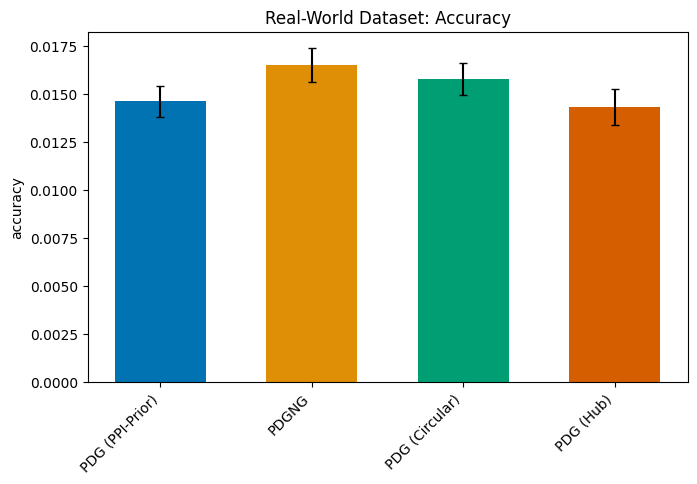

Displayed og pdgrapher data plot for 'pdgrapher': metric='accuracy' (normalize=False)
PDG (PPI-Prior): mean=0.191658398656215, std=0.01292382965770659
PDGNG: mean=0.20103345464725642, std=0.01530792352840937
PDG (Circular): mean=0.21068607689436356, std=0.01716444754554298
PDG (Hub): mean=0.21209101654846338, std=0.025821789986892697


/tmp/ipykernel_3924784/1666659506.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


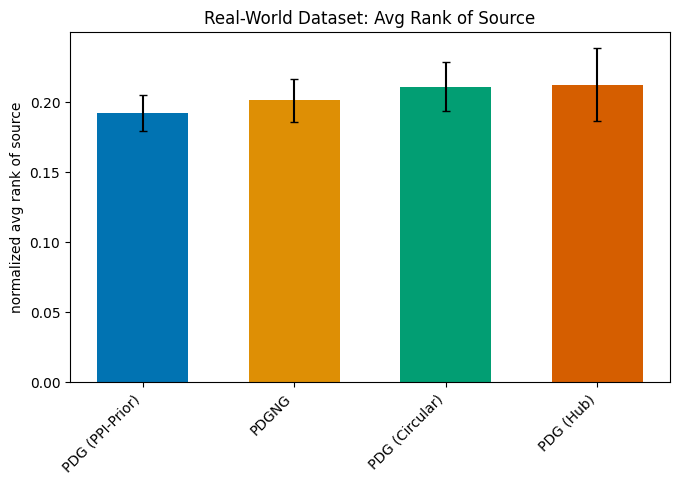

Displayed og pdgrapher data plot for 'pdgrapher': metric='avg rank of source' (normalize=True)
PDG (PPI-Prior): mean=0.101, std=0.004604345773288533
PDGNG: mean=0.098, std=0.0021213203435596446
PDG (Circular): mean=0.0945, std=0.008077747210701754
PDG (Hub): mean=0.09300000000000001, std=0.004546060565661956


/tmp/ipykernel_3924784/1666659506.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


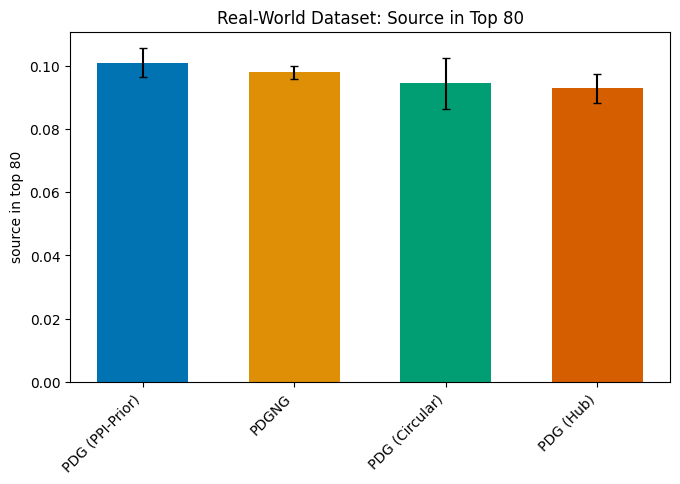

Displayed og pdgrapher data plot for 'pdgrapher': metric='source in top 80' (normalize=False)
PDG (PPI-Prior): mean=0.08824000000000001, std=0.0028548905408088752
PDGNG: mean=0.08795, std=0.0031260998064681165
PDG (Circular): mean=0.086925, std=0.0032475952641916415
PDG (Hub): mean=0.09076666666666666, std=0.0016131404843417153


/tmp/ipykernel_3924784/1666659506.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


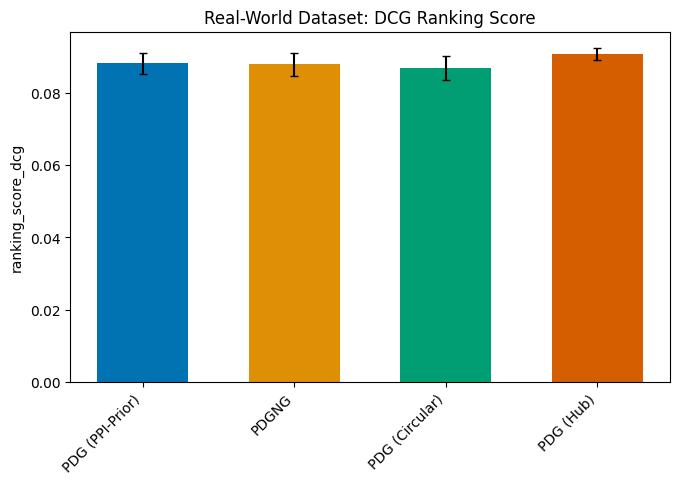

Displayed og pdgrapher data plot for 'pdgrapher': metric='ranking_score_dcg' (normalize=False)


In [17]:
# og_pdgrapher_data("pdgrapher", "avg rank of source", normalize=True, title="OG PDGrapher Datasets: Avg Rank of Source (Normalized)")
og_pdgrapher_data("pdgrapher", "accuracy", normalize=False, title="Real-World Dataset: Accuracy")
og_pdgrapher_data("pdgrapher", "avg rank of source", normalize=True, title="Real-World Dataset: Avg Rank of Source")
# og_pdgrapher_data("pdgrapher", "source in top 20", normalize=False, title="OG PDGrapher Datasets: Source in Top 20")
og_pdgrapher_data("pdgrapher", "source in top 80", normalize=False, title="Real-World Dataset: Source in Top 80")
og_pdgrapher_data("pdgrapher", "ranking_score_dcg", normalize=False, title="Real-World Dataset: DCG Ranking Score", pdg_metric = True)